In [10]:
from collections.abc import Callable
import itertools
import os
import sys
import urllib.request
from pathlib import Path 
import math
import gzip
import pickle

import numpy as np
import pandas as pd
import allel
import zarr
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(precision=4, suppress=True)

# paths

In [11]:
PATH_DATA = Path("_data")
PATH_DATA_RAW = PATH_DATA / "raw"
PATH_DATA_AC = PATH_DATA / "allele_count"
PATH_DATA_SI = PATH_DATA / "sample_indice"

PATH_DATA_RAW.mkdir(parents=True, exist_ok=True)
PATH_DATA_AC.mkdir(parents=True, exist_ok=True)
PATH_DATA_SI.mkdir(parents=True, exist_ok=True)

PATH_OUT = Path("_output")
PATH_OUT_CSV = PATH_OUT / "csv"
PATH_OUT_FIG = PATH_OUT / "fig"

PATH_OUT_CSV.mkdir(parents=True, exist_ok=True)
PATH_OUT_FIG.mkdir(parents=True, exist_ok=True)

# download data

In [12]:
# Custom hook to show download progress in console
def download_progress(count, block_size, total_size):
    percent = int(count * block_size * 100 / total_size)
    print(f"\rDownloading: {percent}% complete", end="")

### download .panel & save as .tsv

In [4]:
url = "http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20130502.ALL.panel"
PATH_PANEL = PATH_DATA_RAW / "sample_panel.tsv"

if not os.path.exists(PATH_PANEL):
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, PATH_PANEL, reporthook=download_progress)
    print(f"\nDownload complete: {PATH_PANEL}")
else:
    print(f"File {PATH_PANEL} already exists. Skipping download.")
    

Downloading: 103% complete
Download complete: _data/raw/sample_panel.tsv


### download .vcf.gz & convert to .zarr

In [5]:
url = "http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"
PATH_CHR22_VCF_GZ = PATH_DATA_RAW / "chr22.vcf.gz"
PATH_CHR22_ZARR = PATH_DATA_RAW / "chr22.zarr"

if not os.path.exists(PATH_CHR22_VCF_GZ):
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, PATH_CHR22_VCF_GZ, reporthook=download_progress)
    print(f"\nDownload complete: {PATH_CHR22_VCF_GZ}")
else:
    print(f"File {PATH_CHR22_VCF_GZ} already exists. Skipping download.")


if not os.path.exists(PATH_CHR22_ZARR):
    print(f"Converting {PATH_CHR22_VCF_GZ} to {PATH_CHR22_ZARR}...")
    allel.vcf_to_zarr(
        input=str(PATH_CHR22_VCF_GZ),
        output=str(PATH_CHR22_ZARR),
        fields=[
            "calldata/GT",
            "variants/POS",
            "variants/REF",
            "variants/ALT",
            "variants/ID",
            "samples",
        ],
        log=sys.stdout,  # Prints progress during chunked conversion
        overwrite=True,
    )
    print(f"Convert complete: {PATH_CHR22_ZARR}!")
else:
    print(f"File '{PATH_CHR22_ZARR}' already exists.")

Downloading: 100% complete
Download complete: _data/raw/chr22.vcf.gz
Converting _data/raw/chr22.vcf.gz to _data/raw/chr22.zarr...
[vcf_to_zarr] 65536 rows in 15.62s; chunk in 15.62s (4194 rows/s); 22 :18539397
[vcf_to_zarr] 131072 rows in 31.17s; chunk in 15.55s (4215 rows/s); 22 :21016127
[vcf_to_zarr] 196608 rows in 46.36s; chunk in 15.19s (4314 rows/s); 22 :23236362
[vcf_to_zarr] 262144 rows in 61.66s; chunk in 15.30s (4283 rows/s); 22 :25227844
[vcf_to_zarr] 327680 rows in 77.18s; chunk in 15.52s (4223 rows/s); 22 :27285434
[vcf_to_zarr] 393216 rows in 92.24s; chunk in 15.06s (4351 rows/s); 22 :29572822
[vcf_to_zarr] 458752 rows in 108.20s; chunk in 15.97s (4104 rows/s); 22 :31900536
[vcf_to_zarr] 524288 rows in 125.00s; chunk in 16.80s (3900 rows/s); 22 :34069864
[vcf_to_zarr] 589824 rows in 140.64s; chunk in 15.64s (4190 rows/s); 22 :36053392
[vcf_to_zarr] 655360 rows in 157.41s; chunk in 16.76s (3909 rows/s); 22 :38088395
[vcf_to_zarr] 720896 rows in 173.33s; chunk in 15.93s (41

# read data

In [13]:
PATH_PANEL = PATH_DATA_RAW / "sample_panel.tsv"
PATH_CHR22_ZARR = PATH_DATA_RAW / "chr22.zarr"

## read sample panel

In [14]:
panel_df = pd.read_csv(PATH_PANEL, sep='\t')

### all

In [15]:
panel_a = panel_df.groupby(["super_pop", "pop"])["sample"].apply(list).to_dict()
pd.Series(panel_a)

AFR  ACB    [HG01879, HG01880, HG01882, HG01883, HG01885, ...
     ASW    [NA19625, NA19700, NA19701, NA19703, NA19704, ...
     ESN    [HG02922, HG02923, HG02938, HG02941, HG02943, ...
     GWD    [HG02461, HG02462, HG02464, HG02465, HG02561, ...
     LWK    [NA19017, NA19019, NA19020, NA19023, NA19024, ...
     MSL    [HG03052, HG03054, HG03055, HG03057, HG03058, ...
     YRI    [NA18486, NA18488, NA18489, NA18498, NA18499, ...
AMR  CLM    [HG01112, HG01113, HG01119, HG01121, HG01122, ...
     MXL    [NA19648, NA19649, NA19651, NA19652, NA19654, ...
     PEL    [HG01565, HG01566, HG01571, HG01572, HG01577, ...
     PUR    [HG00551, HG00553, HG00554, HG00637, HG00638, ...
EAS  CDX    [HG00759, HG00766, HG00844, HG00851, HG00864, ...
     CHB    [NA18525, NA18526, NA18528, NA18530, NA18531, ...
     CHS    [HG00403, HG00404, HG00406, HG00407, HG00409, ...
     JPT    [NA18939, NA18940, NA18941, NA18942, NA18943, ...
     KHV    [HG01595, HG01596, HG01597, HG01598, HG01599, ...
EUR  CEU

### females

In [16]:
panel_f_df = panel_df[panel_df["gender"] == "female"]
panel_f = panel_f_df.groupby(["super_pop", "pop"])["sample"].apply(list).to_dict()
pd.Series(panel_f)

AFR  ACB    [HG01880, HG01883, HG01886, HG01889, HG01894, ...
     ASW    [NA19625, NA19701, NA19704, NA19707, NA19712, ...
     ESN    [HG02922, HG02943, HG02946, HG02952, HG02970, ...
     GWD    [HG02462, HG02465, HG02562, HG02568, HG02571, ...
     LWK    [NA19017, NA19019, NA19023, NA19024, NA19030, ...
     MSL    [HG03052, HG03055, HG03058, HG03061, HG03064, ...
     YRI    [NA18488, NA18489, NA18499, NA18502, NA18505, ...
AMR  CLM    [HG01113, HG01119, HG01122, HG01125, HG01131, ...
     MXL    [NA19648, NA19651, NA19654, NA19657, NA19663, ...
     PEL    [HG01566, HG01572, HG01578, HG01893, HG01918, ...
     PUR    [HG00551, HG00554, HG00638, HG00641, HG00732, ...
EAS  CDX    [HG00759, HG00766, HG00851, HG00864, HG00867, ...
     CHB    [NA18525, NA18526, NA18528, NA18531, NA18532, ...
     CHS    [HG00404, HG00407, HG00410, HG00419, HG00422, ...
     JPT    [NA18939, NA18941, NA18942, NA18946, NA18947, ...
     KHV    [HG01595, HG01597, HG01598, HG01599, HG01600, ...
EUR  CEU

### males

In [17]:
panel_m_df = panel_df[panel_df["gender"] == "male"]
panel_m = panel_m_df.groupby(["super_pop", "pop"])["sample"].apply(list).to_dict()
pd.Series(panel_m)

AFR  ACB    [HG01879, HG01882, HG01885, HG01890, HG01912, ...
     ASW    [NA19700, NA19703, NA19711, NA19818, NA19834, ...
     ESN    [HG02923, HG02938, HG02941, HG02944, HG02947, ...
     GWD    [HG02461, HG02464, HG02561, HG02570, HG02573, ...
     LWK    [NA19020, NA19025, NA19026, NA19027, NA19028, ...
     MSL    [HG03054, HG03057, HG03060, HG03063, HG03066, ...
     YRI    [NA18486, NA18498, NA18501, NA18504, NA18507, ...
AMR  CLM    [HG01112, HG01121, HG01124, HG01130, HG01133, ...
     MXL    [NA19649, NA19652, NA19655, NA19658, NA19661, ...
     PEL    [HG01565, HG01571, HG01577, HG01892, HG01917, ...
     PUR    [HG00553, HG00637, HG00640, HG00731, HG00736, ...
EAS  CDX    [HG00844, HG00881, HG00982, HG01028, HG01031, ...
     CHB    [NA18530, NA18534, NA18536, NA18543, NA18544, ...
     CHS    [HG00403, HG00406, HG00409, HG00421, HG00436, ...
     JPT    [NA18940, NA18943, NA18944, NA18945, NA18948, ...
     KHV    [HG01596, HG01840, HG01842, HG01844, HG01846, ...
EUR  CEU

## read chr22

In [18]:
chr22 = zarr.open_group(PATH_CHR22_ZARR, mode='r')
print(chr22.tree())

/
 ├── calldata
 │   └── GT (1103547, 2504, 2) int8
 ├── samples (2504,) object
 └── variants
     ├── ALT (1103547, 3) object
     ├── ID (1103547,) object
     ├── POS (1103547,) int32
     └── REF (1103547,) object


### chr22 samples

In [19]:
chr22_samples = chr22['samples'][:]
chr22_samples

array(['HG00096', 'HG00097', 'HG00099', ..., 'NA21142', 'NA21143',
       'NA21144'], shape=(2504,), dtype=object)

### chr22 geno types

In [20]:
VARIANT_FROM = None
VARIANT_TO = None

chr22_gt_all = allel.GenotypeChunkedArray(chr22['calldata/GT'])
print("Genotype array shape:", chr22_gt_all.shape)
chr22_gt = chr22_gt_all[VARIANT_FROM:VARIANT_TO]
# chr22_gt.values

Genotype array shape: (1103547, 2504, 2)


# map sample indices

In [21]:
PATH_DATA_SI_A = PATH_DATA_SI / "sample_indice_a.pkl"
PATH_DATA_SI_F = PATH_DATA_SI / "sample_indice_f.pkl"
PATH_DATA_SI_M = PATH_DATA_SI / "sample_indice_m.pkl"

PATH_DATA_SI_SA = PATH_DATA_SI / "sample_indice_sa.pkl"
PATH_DATA_SI_SF = PATH_DATA_SI / "sample_indice_sf.pkl"
PATH_DATA_SI_SM = PATH_DATA_SI / "sample_indice_sm.pkl"

## by super pop

In [22]:
def get_sample_indices(panel: dict, path_pkl: Path):
    if os.path.exists(path_pkl):
        print(f"Reading from... {path_pkl}")
        with gzip.open(path_pkl, "rb") as f:
            return pickle.load(f)
    
    indice = {}
    for (spop, _), sample_list in panel.items():
        idxs = [
            int((chr22_samples == s).argmax())
            for s in sample_list
            if s in chr22_samples
        ]
        if len(idxs) > 0:
            indice[spop] = idxs
            
    with gzip.open(path_pkl, "wb") as f:
        print(f"\nWriting to... {path_pkl}")
        pickle.dump(indice, f)
    
    return indice

### all

In [23]:
sample_indices_sa = get_sample_indices(panel_a, PATH_DATA_SI_SA)
pd.Series(sample_indices_sa)


Writing to... _data/sample_indice/sample_indice_sa.pkl


AFR    [1755, 1756, 1757, 1758, 1759, 1760, 1761, 176...
AMR    [227, 228, 229, 265, 266, 267, 268, 297, 298, ...
EAS    [538, 539, 540, 541, 542, 543, 639, 640, 641, ...
EUR    [2294, 2295, 2296, 2297, 2298, 2299, 2300, 230...
SAS    [1367, 1368, 1369, 1370, 1371, 1379, 1380, 138...
dtype: object

### females

In [24]:
sample_indices_sf = get_sample_indices(panel_f, PATH_DATA_SI_SF)
pd.Series(sample_indices_sf)


Writing to... _data/sample_indice/sample_indice_sf.pkl


AFR    [1756, 1757, 1759, 1761, 1763, 1765, 1767, 176...
AMR    [227, 229, 266, 268, 298, 299, 301, 303, 305, ...
EAS    [538, 540, 541, 542, 543, 640, 642, 644, 646, ...
EUR    [2294, 2295, 2296, 2297, 2298, 2299, 2300, 230...
SAS    [1367, 1368, 1370, 1380, 1384, 1388, 1389, 139...
dtype: object

### males

In [25]:
sample_indices_sm = get_sample_indices(panel_m, PATH_DATA_SI_SM)
pd.Series(sample_indices_sm)


Writing to... _data/sample_indice/sample_indice_sm.pkl


AFR    [1755, 1758, 1760, 1762, 1764, 1766, 1768, 177...
AMR    [228, 265, 267, 297, 300, 302, 304, 321, 322, ...
EAS    [539, 639, 641, 643, 645, 648, 651, 657, 658, ...
EUR    [2301, 2302, 2303, 2304, 2305, 2307, 2308, 231...
SAS    [1369, 1371, 1379, 1381, 1382, 1383, 1385, 138...
dtype: object

## by pop

In [26]:
def get_sample_indices(panel: dict, path_pkl: Path):
    if os.path.exists(path_pkl):
        print(f"Reading from... {path_pkl}")
        with gzip.open(path_pkl, "rb") as f:
            return pickle.load(f)
    
    indices = {}
    for (_, pop), sample_list in panel.items():
        idxs = [
            int((chr22_samples == s).argmax())
            for s in sample_list
            if s in chr22_samples
        ]
        if len(idxs) > 0:
            indices[pop] = idxs
            
    with gzip.open(path_pkl, "wb") as f:
        print(f"\nWriting to... {path_pkl}")
        pickle.dump(indices, f)
    
    return indices

### all

In [27]:
sample_indices_a = get_sample_indices(panel_a, PATH_DATA_SI_A)
pd.Series(sample_indices_a)


Writing to... _data/sample_indice/sample_indice_a.pkl


ACB    [673, 674, 675, 676, 677, 678, 679, 680, 683, ...
ASW    [2169, 2189, 2190, 2191, 2192, 2193, 2194, 219...
ESN    [1123, 1124, 1125, 1126, 1127, 1128, 1129, 113...
GWD    [945, 946, 947, 948, 983, 984, 985, 986, 987, ...
LWK    [1976, 1977, 1978, 1979, 1980, 1981, 1982, 198...
MSL    [1164, 1165, 1166, 1167, 1168, 1169, 1170, 117...
YRI    [1755, 1756, 1757, 1758, 1759, 1760, 1761, 176...
CLM    [362, 363, 364, 365, 366, 367, 368, 369, 370, ...
MXL    [2170, 2171, 2172, 2173, 2174, 2175, 2176, 217...
PEL    [528, 529, 530, 531, 532, 533, 681, 682, 688, ...
PUR    [227, 228, 229, 265, 266, 267, 268, 297, 298, ...
CDX    [306, 307, 308, 309, 310, 311, 312, 313, 314, ...
CHB    [1774, 1775, 1776, 1777, 1778, 1779, 1780, 178...
CHS    [185, 186, 187, 188, 189, 190, 191, 192, 193, ...
JPT    [1906, 1907, 1908, 1909, 1910, 1911, 1912, 191...
KHV    [538, 539, 540, 541, 542, 543, 639, 640, 641, ...
CEU    [1656, 1657, 1658, 1659, 1660, 1661, 1662, 166...
FIN    [55, 56, 57, 58, 59, 60,

### females

In [28]:
sample_indices_f = get_sample_indices(panel_f, PATH_DATA_SI_F)
pd.Series(sample_indices_f)


Writing to... _data/sample_indice/sample_indice_f.pkl


ACB    [674, 676, 678, 679, 683, 684, 687, 712, 713, ...
ASW    [2169, 2190, 2192, 2193, 2195, 2196, 2243, 224...
ESN    [1123, 1127, 1129, 1131, 1134, 1137, 1138, 114...
GWD    [946, 948, 984, 985, 987, 989, 993, 995, 997, ...
LWK    [1976, 1977, 1979, 1980, 1985, 1988, 1989, 199...
MSL    [1164, 1166, 1168, 1170, 1172, 1176, 1180, 118...
YRI    [1756, 1757, 1759, 1761, 1763, 1765, 1767, 176...
CLM    [363, 364, 366, 368, 370, 372, 374, 376, 379, ...
MXL    [2170, 2172, 2174, 2176, 2179, 2181, 2184, 218...
PEL    [529, 531, 533, 682, 689, 691, 693, 695, 697, ...
PUR    [227, 229, 266, 268, 298, 299, 301, 303, 305, ...
CDX    [306, 307, 309, 310, 311, 312, 314, 315, 318, ...
CHB    [1774, 1775, 1776, 1778, 1779, 1780, 1782, 178...
CHS    [186, 188, 190, 191, 193, 194, 196, 198, 200, ...
JPT    [1906, 1908, 1909, 1913, 1914, 1916, 1917, 191...
KHV    [538, 540, 541, 542, 543, 640, 642, 644, 646, ...
CEU    [1657, 1659, 1661, 1662, 1665, 1668, 1671, 167...
FIN    [55, 56, 57, 58, 59, 60,

### males

In [29]:
sample_indices_m = get_sample_indices(panel_m, PATH_DATA_SI_M)
pd.Series(sample_indices_m)


Writing to... _data/sample_indice/sample_indice_m.pkl


ACB    [673, 675, 677, 680, 685, 686, 728, 729, 731, ...
ASW    [2189, 2191, 2194, 2242, 2244, 2246, 2248, 224...
ESN    [1124, 1125, 1126, 1128, 1130, 1132, 1133, 113...
GWD    [945, 947, 983, 986, 988, 992, 994, 996, 998, ...
LWK    [1978, 1981, 1982, 1983, 1984, 1986, 1987, 199...
MSL    [1165, 1167, 1169, 1171, 1173, 1174, 1175, 117...
YRI    [1755, 1758, 1760, 1762, 1764, 1766, 1768, 177...
CLM    [362, 365, 367, 369, 371, 373, 375, 377, 378, ...
MXL    [2171, 2173, 2175, 2177, 2178, 2180, 2182, 218...
PEL    [528, 530, 532, 681, 688, 690, 692, 694, 696, ...
PUR    [228, 265, 267, 297, 300, 302, 304, 321, 322, ...
CDX    [308, 313, 316, 317, 319, 632, 633, 637, 851, ...
CHB    [1777, 1781, 1783, 1789, 1790, 1792, 1794, 179...
CHS    [185, 187, 189, 192, 195, 197, 199, 201, 203, ...
JPT    [1907, 1910, 1911, 1912, 1915, 1919, 1920, 192...
KHV    [539, 639, 641, 643, 645, 648, 651, 657, 658, ...
CEU    [1656, 1658, 1660, 1663, 1664, 1666, 1667, 166...
FIN    [63, 64, 65, 66, 67, 68,

# pop & allele count

In [30]:
PATH_DATA_AC_SA = PATH_DATA_AC / "ac_sa.pkl.gz"
PATH_DATA_AC_SF = PATH_DATA_AC / "ac_sf.pkl.gz"
PATH_DATA_AC_SM = PATH_DATA_AC / "ac_sm.pkl.gz"

PATH_DATA_AC_A = PATH_DATA_AC / "ac_a.pkl.gz"
PATH_DATA_AC_F = PATH_DATA_AC / "ac_f.pkl.gz"
PATH_DATA_AC_M = PATH_DATA_AC / "ac_m.pkl.gz"

In [31]:
def get_ac(sample_indices, path_pkl):
    if os.path.exists(path_pkl):
        print(f"Reading from... {path_pkl}")
        with gzip.open(path_pkl, "rb") as f:
            return pickle.load(f)     
    
    # ac = {
    #     pop: chr22_gt.take(indices, axis=1).count_alleles()
    #     for pop, indices in sample_indice.items()
    # }
    ac = {}
    prog_curr, prog_total = 1, len(sample_indices)
    for pop, indices in sample_indices.items():
        ac[pop] = chr22_gt.take(indices, axis=1).count_alleles()
        sys.stdout.write(
            f"\rCalculating ac... [{prog_curr}/{prog_total}] {prog_curr/prog_total*100:.1f}%"
        )
        sys.stdout.flush()
        prog_curr += 1
    
    with gzip.open(path_pkl, "wb") as f:
        print(f"\nWriting to... {path_pkl}")
        pickle.dump(ac, f)
        
    return ac

## by super pop

### all

In [32]:
ac_sa = get_ac(sample_indices_sa, PATH_DATA_AC_SA)
pd.Series(ac_sa)

Calculating ac... [5/5] 100.0%
Writing to... _data/allele_count/ac_sa.pkl.gz


AFR    [[216, 0, 0, 0, 0, 0, 0, 0], [206, 10, 0, 0, 0...
AMR    [[208, 0, 0, 0, 0, 0, 0], [208, 0, 0, 0, 0, 0,...
EAS    [[198, 0, 0, 0, 0, 0, 0, 0], [198, 0, 0, 0, 0,...
EUR    [[214, 0, 0, 0, 0, 0, 0, 0], [214, 0, 0, 0, 0,...
SAS    [[204, 0, 0, 0, 0, 0, 0], [204, 0, 0, 0, 0, 0,...
dtype: object

### females

In [33]:
ac_sf = get_ac(sample_indices_sf, PATH_DATA_AC_SF)
pd.Series(ac_sf)

Calculating ac... [5/5] 100.0%
Writing to... _data/allele_count/ac_sf.pkl.gz


AFR    [[112, 0, 0, 0, 0, 0, 0, 0], [109, 3, 0, 0, 0,...
AMR    [[100, 0, 0, 0, 0, 0, 0], [100, 0, 0, 0, 0, 0,...
EAS    [[106, 0, 0, 0, 0, 0, 0, 0], [106, 0, 0, 0, 0,...
EUR    [[108, 0, 0, 0, 0, 0, 0, 0], [108, 0, 0, 0, 0,...
SAS    [[94, 0, 0, 0, 0, 0, 0], [94, 0, 0, 0, 0, 0, 0...
dtype: object

### males

In [34]:
ac_sm = get_ac(sample_indices_sm, PATH_DATA_AC_SM)
pd.Series(ac_sm)

Calculating ac... [5/5] 100.0%
Writing to... _data/allele_count/ac_sm.pkl.gz


AFR    [[104, 0, 0, 0, 0, 0, 0, 0], [97, 7, 0, 0, 0, ...
AMR    [[108, 0, 0, 0, 0, 0, 0], [108, 0, 0, 0, 0, 0,...
EAS    [[92, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0, 0...
EUR    [[106, 0, 0, 0, 0, 0, 0], [106, 0, 0, 0, 0, 0,...
SAS    [[110, 0, 0, 0, 0, 0, 0], [110, 0, 0, 0, 0, 0,...
dtype: object

## by pop

### all

In [35]:
ac_a = get_ac(sample_indices_a, PATH_DATA_AC_A)
pd.Series(ac_a)

Calculating ac... [26/26] 100.0%
Writing to... _data/allele_count/ac_a.pkl.gz


ACB    [[192, 0, 0, 0, 0, 0, 0, 0, 0], [188, 4, 0, 0,...
ASW    [[122, 0, 0, 0, 0, 0, 0, 0, 0], [118, 4, 0, 0,...
ESN    [[198, 0, 0, 0, 0, 0, 0, 0], [196, 2, 0, 0, 0,...
GWD    [[226, 0, 0, 0, 0, 0, 0, 0], [223, 3, 0, 0, 0,...
LWK    [[198, 0, 0, 0, 0, 0, 0, 0], [196, 2, 0, 0, 0,...
MSL    [[170, 0, 0, 0, 0, 0, 0, 0, 0], [164, 6, 0, 0,...
YRI    [[216, 0, 0, 0, 0, 0, 0, 0], [206, 10, 0, 0, 0...
CLM    [[188, 0, 0, 0, 0, 0, 0, 0], [187, 1, 0, 0, 0,...
MXL    [[128, 0, 0, 0, 0, 0, 0, 0], [128, 0, 0, 0, 0,...
PEL    [[170, 0, 0, 0, 0, 0, 0, 0], [170, 0, 0, 0, 0,...
PUR    [[208, 0, 0, 0, 0, 0, 0], [208, 0, 0, 0, 0, 0,...
CDX    [[186, 0, 0, 0, 0, 0, 0, 0], [186, 0, 0, 0, 0,...
CHB    [[206, 0, 0, 0, 0, 0, 0, 0, 0], [206, 0, 0, 0,...
CHS    [[210, 0, 0, 0, 0, 0, 0, 0], [210, 0, 0, 0, 0,...
JPT    [[208, 0, 0, 0, 0, 0, 0, 0], [208, 0, 0, 0, 0,...
KHV    [[198, 0, 0, 0, 0, 0, 0, 0], [198, 0, 0, 0, 0,...
CEU    [[198, 0, 0, 0, 0, 0, 0], [198, 0, 0, 0, 0, 0,...
FIN    [[198, 0, 0, 0, 0, 0, 0,

### females

In [36]:
ac_f = get_ac(sample_indices_f, PATH_DATA_AC_F)
pd.Series(ac_f)

Calculating ac... [26/26] 100.0%
Writing to... _data/allele_count/ac_f.pkl.gz


ACB    [[98, 0, 0, 0, 0, 0, 0, 0, 0], [97, 1, 0, 0, 0...
ASW    [[70, 0, 0, 0, 0, 0, 0, 0, 0], [67, 3, 0, 0, 0...
ESN    [[92, 0, 0, 0, 0, 0, 0, 0], [91, 1, 0, 0, 0, 0...
GWD    [[116, 0, 0, 0, 0, 0, 0, 0], [114, 2, 0, 0, 0,...
LWK    [[110, 0, 0, 0, 0, 0, 0, 0], [109, 1, 0, 0, 0,...
MSL    [[86, 0, 0, 0, 0, 0, 0, 0], [83, 3, 0, 0, 0, 0...
YRI    [[112, 0, 0, 0, 0, 0, 0, 0], [109, 3, 0, 0, 0,...
CLM    [[102, 0, 0, 0, 0, 0, 0, 0], [101, 1, 0, 0, 0,...
MXL    [[64, 0, 0, 0, 0, 0, 0], [64, 0, 0, 0, 0, 0, 0...
PEL    [[88, 0, 0, 0, 0, 0, 0], [88, 0, 0, 0, 0, 0, 0...
PUR    [[100, 0, 0, 0, 0, 0, 0], [100, 0, 0, 0, 0, 0,...
CDX    [[98, 0, 0, 0, 0, 0, 0, 0], [98, 0, 0, 0, 0, 0...
CHB    [[114, 0, 0, 0, 0, 0, 0, 0], [114, 0, 0, 0, 0,...
CHS    [[106, 0, 0, 0, 0, 0, 0, 0], [106, 0, 0, 0, 0,...
JPT    [[96, 0, 0, 0, 0, 0, 0, 0], [96, 0, 0, 0, 0, 0...
KHV    [[106, 0, 0, 0, 0, 0, 0, 0], [106, 0, 0, 0, 0,...
CEU    [[100, 0, 0, 0, 0, 0, 0], [100, 0, 0, 0, 0, 0,...
FIN    [[122, 0, 0, 0, 0, 0, 0,

### males

In [37]:
ac_m = get_ac(sample_indices_m, PATH_DATA_AC_M)
pd.Series(ac_m)

Calculating ac... [26/26] 100.0%
Writing to... _data/allele_count/ac_m.pkl.gz


ACB    [[94, 0, 0, 0, 0, 0, 0, 0], [91, 3, 0, 0, 0, 0...
ASW    [[52, 0, 0, 0, 0, 0, 0], [51, 1, 0, 0, 0, 0, 0...
ESN    [[106, 0, 0, 0, 0, 0, 0, 0], [105, 1, 0, 0, 0,...
GWD    [[110, 0, 0, 0, 0, 0, 0], [109, 1, 0, 0, 0, 0,...
LWK    [[88, 0, 0, 0, 0, 0, 0, 0], [87, 1, 0, 0, 0, 0...
MSL    [[84, 0, 0, 0, 0, 0, 0, 0, 0], [81, 3, 0, 0, 0...
YRI    [[104, 0, 0, 0, 0, 0, 0, 0], [97, 7, 0, 0, 0, ...
CLM    [[86, 0, 0, 0, 0, 0, 0, 0], [86, 0, 0, 0, 0, 0...
MXL    [[64, 0, 0, 0, 0, 0, 0, 0], [64, 0, 0, 0, 0, 0...
PEL    [[82, 0, 0, 0, 0, 0, 0, 0], [82, 0, 0, 0, 0, 0...
PUR    [[108, 0, 0, 0, 0, 0, 0], [108, 0, 0, 0, 0, 0,...
CDX    [[88, 0, 0, 0, 0, 0, 0, 0], [88, 0, 0, 0, 0, 0...
CHB    [[92, 0, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0...
CHS    [[104, 0, 0, 0, 0, 0, 0, 0], [104, 0, 0, 0, 0,...
JPT    [[112, 0, 0, 0, 0, 0, 0, 0], [112, 0, 0, 0, 0,...
KHV    [[92, 0, 0, 0, 0, 0, 0, 0], [92, 0, 0, 0, 0, 0...
CEU    [[98, 0, 0, 0, 0, 0, 0], [98, 0, 0, 0, 0, 0, 0...
FIN    [[76, 0, 0, 0, 0, 0, 0, 

# calculate fst

In [38]:
PATH_OUT_FST_SA = PATH_OUT_CSV / "fst_sa.csv"
PATH_OUT_FST_SF = PATH_OUT_CSV / "fst_sf.csv"
PATH_OUT_FST_SM = PATH_OUT_CSV / "fst_sm.csv"

PATH_OUT_FST_A = PATH_OUT_CSV / "fst_a.csv"
PATH_OUT_FST_F = PATH_OUT_CSV / "fst_f.csv"
PATH_OUT_FST_M = PATH_OUT_CSV / "fst_m.csv"
PATH_OUT_FST_D = PATH_OUT_CSV / "fst_d.csv"

In [39]:
pop_names_dict = {
    "AFR": ["YRI", "LWK", "GWD", "MSL", "ESN", "ASW", "ACB"],
    "EUR": ["CEU", "TSI", "FIN", "GBR", "IBS"],
    "EAS": ["CHB", "JPT", "CHS", "CDX", "KHV"],
    "SAS": ["GIH", "PJL", "STU", "ITU", "BEB"],
    "AMR": ["MXL", "PUR", "CLM", "PEL"],
}
pop_names_dict = {k: sorted(v) for k, v in sorted(pop_names_dict.items())}
pop_names = [(spop, pop) for spop, pops in pop_names_dict.items() for pop in pops]
super_pop_names = [spop for spop, _ in pop_names_dict.items()]
print(super_pop_names)
pop_names

['AFR', 'AMR', 'EAS', 'EUR', 'SAS']


[('AFR', 'ACB'),
 ('AFR', 'ASW'),
 ('AFR', 'ESN'),
 ('AFR', 'GWD'),
 ('AFR', 'LWK'),
 ('AFR', 'MSL'),
 ('AFR', 'YRI'),
 ('AMR', 'CLM'),
 ('AMR', 'MXL'),
 ('AMR', 'PEL'),
 ('AMR', 'PUR'),
 ('EAS', 'CDX'),
 ('EAS', 'CHB'),
 ('EAS', 'CHS'),
 ('EAS', 'JPT'),
 ('EAS', 'KHV'),
 ('EUR', 'CEU'),
 ('EUR', 'FIN'),
 ('EUR', 'GBR'),
 ('EUR', 'IBS'),
 ('EUR', 'TSI'),
 ('SAS', 'BEB'),
 ('SAS', 'GIH'),
 ('SAS', 'ITU'),
 ('SAS', 'PJL'),
 ('SAS', 'STU')]

## by super pop

In [40]:
def get_fst_super(ac_dict: dict, path_csv: Path):
    if os.path.exists(path_csv):
        print(f"Reading from... {path_csv}")
        return pd.read_csv(path_csv, header=0, index_col=0)

    n_pops = len(super_pop_names)
    fst = np.zeros((n_pops, n_pops))

    prog_curr, prog_total = 1, math.comb(n_pops, 2)
    for i, j in itertools.combinations(range(n_pops), 2):
        sp1, sp2 = super_pop_names[i], super_pop_names[j]
        ac1, ac2 = ac_dict[sp1], ac_dict[sp2]

        # filter for biallelic variants across the population pair
        is_biallelic = (ac1.max_allele() <= 1) & (ac2.max_allele() <= 1)
        num, den = allel.hudson_fst(ac1[is_biallelic], ac2[is_biallelic])

        fst_val = np.sum(num) / np.sum(den)
        fst[i, j] = max(0.0, fst_val)  # floor sampling noise near zero
        fst[j, i] = max(0.0, fst_val)

        sys.stdout.write(
            f"\rCalculating Fst... [{prog_curr}/{prog_total}] {prog_curr/prog_total*100:.1f}%"
        )
        sys.stdout.flush()
        prog_curr += 1

    df = pd.DataFrame(fst, index=super_pop_names, columns=super_pop_names)

    print(f"\nWriting to... {path_csv}")
    df.to_csv(path_csv)
    return df

### all

In [41]:
df_fst_sa = get_fst_super(ac_sa, PATH_OUT_FST_SA)
df_fst_sa.round(4)

Calculating Fst... [10/10] 100.0%
Writing to... _output/csv/fst_sa.csv


,AFR,AMR,EAS,EUR,SAS
AFR,0.0000,0.1051,0.1709,0.1341,0.1297
AMR,0.1051,0.0000,0.0888,0.0081,0.0331
EAS,0.1709,0.0888,0.0000,0.1066,0.0697
EUR,0.1341,0.0081,0.1066,0.0000,0.0397
SAS,0.1297,0.0331,0.0697,0.0397,0.0000


### females

In [42]:
df_fst_sf = get_fst_super(ac_sf, PATH_OUT_FST_SF)
df_fst_sf.round(4)

Calculating Fst... [10/10] 100.0%
Writing to... _output/csv/fst_sf.csv


,AFR,AMR,EAS,EUR,SAS
AFR,0.0000,0.1029,0.1707,0.1351,0.1288
AMR,0.1029,0.0000,0.0907,0.0090,0.0336
EAS,0.1707,0.0907,0.0000,0.1076,0.0705
EUR,0.1351,0.0090,0.1076,0.0000,0.0401
SAS,0.1288,0.0336,0.0705,0.0401,0.0000


### males

In [43]:
df_fst_sm = get_fst_super(ac_sm, PATH_OUT_FST_SM)
df_fst_sm.round(4)

Calculating Fst... [10/10] 100.0%
Writing to... _output/csv/fst_sm.csv


,AFR,AMR,EAS,EUR,SAS
AFR,0.0000,0.1070,0.1710,0.1333,0.1303
AMR,0.1070,0.0000,0.0866,0.0077,0.0328
EAS,0.1710,0.0866,0.0000,0.1057,0.0689
EUR,0.1333,0.0077,0.1057,0.0000,0.0395
SAS,0.1303,0.0328,0.0689,0.0395,0.0000


### absolute difference

In [44]:
df_abs_diff_s = df_fst_sf - df_fst_sm
df_abs_diff_s.round(4)

,AFR,AMR,EAS,EUR,SAS
AFR,0.0000,-0.0041,-0.0003,0.0018,-0.0015
AMR,-0.0041,0.0000,0.0042,0.0013,0.0008
EAS,-0.0003,0.0042,0.0000,0.0019,0.0016
EUR,0.0018,0.0013,0.0019,0.0000,0.0006
SAS,-0.0015,0.0008,0.0016,0.0006,0.0000


### relative difference

In [45]:
df_rel_diff_s = df_abs_diff_s / (df_fst_sf + df_fst_sm)
df_rel_diff_s.round(4)

,AFR,AMR,EAS,EUR,SAS
AFR,NaN,-0.0196,-0.0009,0.0068,-0.0058
AMR,-0.0196,NaN,0.0234,0.0779,0.0128
EAS,-0.0009,0.0234,NaN,0.0091,0.0113
EUR,0.0068,0.0779,0.0091,NaN,0.0074
SAS,-0.0058,0.0128,0.0113,0.0074,NaN


### migration ratio

In [46]:
df_migr_sm = (1 - df_fst_sm) / (4 * np.maximum(df_fst_sm, 1e-6))
df_migr_sf = (1 - df_fst_sf) / (4 * np.maximum(df_fst_sf, 1e-6))

# df_migr_ratio_s = np.log2(df_migr_sm / df_migr_sf)
df_migr_ratio_s = df_migr_sm / df_migr_sf
df_migr_ratio_s = df_migr_ratio_s.mask(df_migr_ratio_s < 1, -1 / df_migr_ratio_s)
df_migr_ratio_s

,AFR,AMR,EAS,EUR,SAS
AFR,1.000000,-1.044887,-1.002173,1.015843,-1.013424
AMR,-1.044887,1.000000,1.052760,1.170446,1.026768
EAS,-1.002173,1.052760,1.000000,1.020488,1.024505
EUR,1.015843,1.170446,1.020488,1.000000,1.015569
SAS,-1.013424,1.026768,1.024505,1.015569,1.000000


## by pop

In [47]:
def get_fst(ac_dict: dict, path_csv: Path):
    if os.path.exists(path_csv):
        print(f"Reading from... {path_csv}")
        # return pd.read_csv(path_csv)
        return pd.read_csv(path_csv, header=[0, 1], index_col=[0, 1])

    n_pops = len(pop_names)
    fst = np.zeros((n_pops, n_pops))

    prog_curr, prog_total = 1, math.comb(n_pops, 2)
    for i, j in itertools.combinations(range(n_pops), 2):
        (_, p1), (_, p2) = pop_names[i], pop_names[j]
        ac1, ac2 = ac_dict[p1], ac_dict[p2]

        # filter for biallelic variants
        is_biallelic = (ac1.max_allele() <= 1) & (ac2.max_allele() <= 1)
        num, den = allel.hudson_fst(ac1[is_biallelic], ac2[is_biallelic])

        fst_val = np.sum(num) / np.sum(den)
        fst[i, j] = max(0.0, fst_val)  # flooring noise near zero
        fst[j, i] = max(0.0, fst_val)

        sys.stdout.write(
            f"\rCalculating Fst... [{prog_curr}/{prog_total}] {prog_curr/prog_total*100:.1f}%"
        )
        sys.stdout.flush()
        prog_curr += 1

    index = pd.MultiIndex.from_tuples(pop_names)
    df = pd.DataFrame(fst, index=index, columns=index)

    print(f"\nWriting to... {path_csv}")
    df.to_csv(path_csv)
    return df

### all

In [48]:
df_fst_a = get_fst(ac_a, PATH_OUT_FST_A)
df_fst_a.round(4)

Calculating Fst... [325/325] 100.0%
Writing to... _output/csv/fst_a.csv


AFR                                                     AMR  \
            ACB     ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB  0.0000  0.0030  0.0046  0.0065  0.0073  0.0048  0.0035  0.0884   
    ASW  0.0030  0.0000  0.0127  0.0125  0.0119  0.0123  0.0122  0.0631   
    ESN  0.0046  0.0127  0.0000  0.0086  0.0087  0.0053  0.0010  0.1199   
    GWD  0.0065  0.0125  0.0086  0.0000  0.0113  0.0041  0.0072  0.1130   
    LWK  0.0073  0.0119  0.0087  0.0113  0.0000  0.0097  0.0087  0.1072   
    MSL  0.0048  0.0123  0.0053  0.0041  0.0097  0.0000  0.0041  0.1165   
    YRI  0.0035  0.0122  0.0010  0.0072  0.0087  0.0041  0.0000  0.1188   
AMR CLM  0.0884  0.0631  0.1199  0.1130  0.1072  0.1165  0.1188  0.0000   
    MXL  0.1118  0.0854  0.1435  0.1369  0.1308  0.1399  0.1424  0.0116   
    PEL  0.1531  0.1269  0.1838  0.1769  0.1708  0.1798  0.1823  0.0473   
    PUR  0.0757  0.0525  0.1060  0.0997  0.0943  0.1030  0.1051  0.0045   
EAS CDX  0.1481  0.1277  0.1756  0.1704  0.1635  0.1725  0.1753  0.0901   
    CHB  0.1453  0.1241  0.1730  0.1682  0.1613  0.1703  0.1729  0.0824   
    CHS  0.1468  0.1259  0.1746  0.1697  0.1630  0.1719  0.1744  0.0847   
    JPT  0.1472  0.1261  0.1754  0.1701  0.1633  0.1725  0.1749  0.0818   
    KHV  0.1437  0.1233  0.1712  0.1662  0.1593  0.1683  0.1709  0.0856   
EUR CEU  0.1052  0.0786  0.1395  0.1327  0.1261  0.1361  0.1387  0.0151   
    FIN  0.1089  0.0824  0.1432  0.1363  0.1301  0.1396  0.1423  0.0201   
    GBR  0.1064  0.0794  0.1408  0.1338  0.1273  0.1373  0.1398  0.0150   
    IBS  0.1023  0.0763  0.1361  0.1292  0.1230  0.1328  0.1352  0.0141   
    TSI  0.1013  0.0755  0.1346  0.1280  0.1215  0.1315  0.1341  0.0146   
SAS BEB  0.1003  0.0781  0.1302  0.1241  0.1175  0.1270  0.1295  0.0327   
    GIH  0.1009  0.0778  0.1320  0.1253  0.1186  0.1284  0.1308  0.0300   
    ITU  0.1005  0.0784  0.1306  0.1242  0.1175  0.1271  0.1298  0.0336   
    PJL  0.0963  0.0733  0.1273  0.1207  0.1144  0.1239  0.1265  0.0251   
    STU  0.1006  0.0782  0.1307  0.1244  0.1179  0.1274  0.1297  0.0329   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB  0.1118  0.1531  0.0757  0.1481  0.1453  0.1468  0.1472  0.1437   
    ASW  0.0854  0.1269  0.0525  0.1277  0.1241  0.1259  0.1261  0.1233   
    ESN  0.1435  0.1838  0.1060  0.1756  0.1730  0.1746  0.1754  0.1712   
    GWD  0.1369  0.1769  0.0997  0.1704  0.1682  0.1697  0.1701  0.1662   
    LWK  0.1308  0.1708  0.0943  0.1635  0.1613  0.1630  0.1633  0.1593   
    MSL  0.1399  0.1798  0.1030  0.1725  0.1703  0.1719  0.1725  0.1683   
    YRI  0.1424  0.1823  0.1051  0.1753  0.1729  0.1744  0.1749  0.1709   
AMR CLM  0.0116  0.0473  0.0045  0.0901  0.0824  0.0847  0.0818  0.0856   
    MXL  0.0000  0.0209  0.0230  0.0859  0.0767  0.0786  0.0757  0.0819   
    PEL  0.0209  0.0000  0.0670  0.1101  0.1008  0.1018  0.0997  0.1073   
    PUR  0.0230  0.0670  0.0000  0.0936  0.0866  0.0890  0.0862  0.0888   
EAS CDX  0.0859  0.1101  0.0936  0.0000  0.0080  0.0052  0.0184  0.0015   
    CHB  0.0767  0.1008  0.0866  0.0080  0.0000  0.0004  0.0081  0.0064   
    CHS  0.0786  0.1018  0.0890  0.0052  0.0004  0.0000  0.0090  0.0040   
    JPT  0.0757  0.0997  0.0862  0.0184  0.0081  0.0090  0.0000  0.0159   
    KHV  0.0819  0.1073  0.0888  0.0015  0.0064  0.0040  0.0159  0.0000   
EUR CEU  0.0415  0.0984  0.0099  0.1141  0.1066  0.1095  0.1054  0.1085   
    FIN  0.0404  0.0926  0.0156  0.1054  0.0972  0.1000  0.0960  0.1003   
    GBR  0.0410  0.0978  0.0094  0.1152  0.1072  0.1104  0.1062  0.1095   
    IBS  0.0423  0.1000  0.0078  0.1133  0.1058  0.1088  0.1046  0.1079   
    TSI  0.0420  0.0994  0.0081  0.1124  0.1043  0.1076  0.1032  0.1066   
SAS BEB  0.0426  0.0825  0.0338  0.0618  0.0575  0.0596  0.0594  0.0566   
    GIH  0.0439  0.0858  0.0301  0.0833  0.0779  0.0803  0.0780  0.0777   
    ITU  0.0458  0.0868  0.0340  0.0

### females

In [49]:
df_fst_f = get_fst(ac_f, PATH_OUT_FST_F)
df_fst_f.round(4)

Calculating Fst... [325/325] 100.0%
Writing to... _output/csv/fst_f.csv


AFR                                                     AMR  \
            ACB     ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB  0.0000  0.0061  0.0044  0.0066  0.0069  0.0046  0.0029  0.0910   
    ASW  0.0061  0.0000  0.0194  0.0176  0.0161  0.0182  0.0179  0.0533   
    ESN  0.0044  0.0194  0.0000  0.0095  0.0084  0.0052  0.0013  0.1226   
    GWD  0.0066  0.0176  0.0095  0.0000  0.0111  0.0046  0.0074  0.1142   
    LWK  0.0069  0.0161  0.0084  0.0111  0.0000  0.0093  0.0080  0.1093   
    MSL  0.0046  0.0182  0.0052  0.0046  0.0093  0.0000  0.0044  0.1177   
    YRI  0.0029  0.0179  0.0013  0.0074  0.0080  0.0044  0.0000  0.1200   
AMR CLM  0.0910  0.0533  0.1226  0.1142  0.1093  0.1177  0.1200  0.0000   
    MXL  0.1107  0.0709  0.1421  0.1335  0.1290  0.1369  0.1397  0.0100   
    PEL  0.1504  0.1116  0.1809  0.1722  0.1680  0.1757  0.1780  0.0455   
    PUR  0.0750  0.0411  0.1055  0.0971  0.0927  0.1006  0.1029  0.0050   
EAS CDX  0.1498  0.1189  0.1776  0.1714  0.1661  0.1733  0.1762  0.0916   
    CHB  0.1446  0.1124  0.1725  0.1667  0.1613  0.1684  0.1713  0.0810   
    CHS  0.1479  0.1161  0.1759  0.1698  0.1650  0.1719  0.1750  0.0849   
    JPT  0.1482  0.1160  0.1768  0.1704  0.1652  0.1724  0.1752  0.0809   
    KHV  0.1444  0.1138  0.1720  0.1662  0.1611  0.1679  0.1707  0.0871   
EUR CEU  0.1055  0.0662  0.1401  0.1316  0.1261  0.1350  0.1376  0.0147   
    FIN  0.1101  0.0708  0.1447  0.1359  0.1308  0.1389  0.1421  0.0200   
    GBR  0.1073  0.0676  0.1421  0.1332  0.1281  0.1366  0.1394  0.0151   
    IBS  0.1030  0.0646  0.1371  0.1283  0.1233  0.1317  0.1344  0.0132   
    TSI  0.1035  0.0651  0.1374  0.1286  0.1235  0.1323  0.1351  0.0151   
SAS BEB  0.1007  0.0673  0.1311  0.1233  0.1179  0.1262  0.1286  0.0315   
    GIH  0.1031  0.0690  0.1349  0.1261  0.1205  0.1292  0.1318  0.0319   
    ITU  0.0998  0.0671  0.1304  0.1227  0.1170  0.1254  0.1277  0.0332   
    PJL  0.0970  0.0629  0.1285  0.1203  0.1151  0.1234  0.1258  0.0249   
    STU  0.1008  0.0683  0.1319  0.1240  0.1185  0.1268  0.1288  0.0339   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB  0.1107  0.1504  0.0750  0.1498  0.1446  0.1479  0.1482  0.1444   
    ASW  0.0709  0.1116  0.0411  0.1189  0.1124  0.1161  0.1160  0.1138   
    ESN  0.1421  0.1809  0.1055  0.1776  0.1725  0.1759  0.1768  0.1720   
    GWD  0.1335  0.1722  0.0971  0.1714  0.1667  0.1698  0.1704  0.1662   
    LWK  0.1290  0.1680  0.0927  0.1661  0.1613  0.1650  0.1652  0.1611   
    MSL  0.1369  0.1757  0.1006  0.1733  0.1684  0.1719  0.1724  0.1679   
    YRI  0.1397  0.1780  0.1029  0.1762  0.1713  0.1750  0.1752  0.1707   
AMR CLM  0.0100  0.0455  0.0050  0.0916  0.0810  0.0849  0.0809  0.0871   
    MXL  0.0000  0.0200  0.0213  0.0831  0.0721  0.0755  0.0720  0.0803   
    PEL  0.0200  0.0000  0.0655  0.1105  0.0995  0.1024  0.0977  0.1086   
    PUR  0.0213  0.0655  0.0000  0.0955  0.0859  0.0899  0.0867  0.0907   
EAS CDX  0.0831  0.1105  0.0955  0.0000  0.0083  0.0058  0.0188  0.0020   
    CHB  0.0721  0.0995  0.0859  0.0083  0.0000  0.0007  0.0082  0.0068   
    CHS  0.0755  0.1024  0.0899  0.0058  0.0007  0.0000  0.0092  0.0040   
    JPT  0.0720  0.0977  0.0867  0.0188  0.0082  0.0092  0.0000  0.0164   
    KHV  0.0803  0.1086  0.0907  0.0020  0.0068  0.0040  0.0164  0.0000   
EUR CEU  0.0379  0.0957  0.0098  0.1159  0.1064  0.1100  0.1059  0.1102   
    FIN  0.0368  0.0932  0.0158  0.1063  0.0960  0.1000  0.0957  0.1013   
    GBR  0.0383  0.0964  0.0097  0.1168  0.1055  0.1102  0.1060  0.1108   
    IBS  0.0393  0.0976  0.0078  0.1138  0.1036  0.1079  0.1029  0.1078   
    TSI  0.0399  0.0985  0.0090  0.1138  0.1031  0.1074  0.1027  0.1076   
SAS BEB  0.0383  0.0794  0.0329  0.0609  0.0544  0.0586  0.0579  0.0561   
    GIH  0.0437  0.0862  0.0320  0.0838  0.0765  0.0811  0.0784  0.0796   
    ITU  0.0420  0.0846  0.0331  0.0

### males

In [50]:
df_fst_m = get_fst(ac_m, PATH_OUT_FST_M)
df_fst_m.round(4)

Calculating Fst... [325/325] 100.0%
Writing to... _output/csv/fst_m.csv


AFR                                                     AMR  \
            ACB     ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB  0.0000  0.0003  0.0041  0.0060  0.0080  0.0049  0.0036  0.0851   
    ASW  0.0003  0.0000  0.0056  0.0069  0.0081  0.0060  0.0055  0.0773   
    ESN  0.0041  0.0056  0.0000  0.0072  0.0091  0.0046  0.0007  0.1165   
    GWD  0.0060  0.0069  0.0072  0.0000  0.0115  0.0032  0.0067  0.1110   
    LWK  0.0080  0.0081  0.0091  0.0115  0.0000  0.0100  0.0100  0.1044   
    MSL  0.0049  0.0060  0.0046  0.0032  0.0100  0.0000  0.0038  0.1143   
    YRI  0.0036  0.0055  0.0007  0.0067  0.0100  0.0038  0.0000  0.1169   
AMR CLM  0.0851  0.0773  0.1165  0.1110  0.1044  0.1143  0.1169  0.0000   
    MXL  0.1129  0.1053  0.1451  0.1402  0.1328  0.1427  0.1452  0.0123   
    PEL  0.1557  0.1478  0.1866  0.1815  0.1738  0.1836  0.1865  0.0483   
    PUR  0.0759  0.0687  0.1064  0.1020  0.0957  0.1050  0.1070  0.0038   
EAS CDX  0.1462  0.1410  0.1738  0.1695  0.1609  0.1713  0.1744  0.0887   
    CHB  0.1456  0.1404  0.1736  0.1698  0.1614  0.1722  0.1745  0.0831   
    CHS  0.1453  0.1398  0.1730  0.1693  0.1609  0.1716  0.1739  0.0840   
    JPT  0.1460  0.1406  0.1740  0.1699  0.1615  0.1724  0.1745  0.0825   
    KHV  0.1423  0.1372  0.1702  0.1661  0.1573  0.1683  0.1710  0.0834   
EUR CEU  0.1046  0.0957  0.1388  0.1339  0.1262  0.1369  0.1397  0.0155   
    FIN  0.1073  0.0992  0.1419  0.1367  0.1297  0.1400  0.1422  0.0196   
    GBR  0.1049  0.0961  0.1393  0.1341  0.1265  0.1375  0.1401  0.0140   
    IBS  0.1013  0.0925  0.1350  0.1300  0.1227  0.1335  0.1357  0.0137   
    TSI  0.0988  0.0905  0.1322  0.1276  0.1199  0.1307  0.1333  0.0141   
SAS BEB  0.0998  0.0933  0.1292  0.1247  0.1168  0.1273  0.1299  0.0332   
    GIH  0.0989  0.0914  0.1297  0.1246  0.1170  0.1277  0.1302  0.0278   
    ITU  0.1003  0.0942  0.1303  0.1253  0.1177  0.1279  0.1311  0.0333   
    PJL  0.0954  0.0887  0.1261  0.1210  0.1137  0.1240  0.1270  0.0242   
    STU  0.1002  0.0932  0.1297  0.1250  0.1176  0.1279  0.1303  0.0318   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB  0.1129  0.1557  0.0759  0.1462  0.1456  0.1453  0.1460  0.1423   
    ASW  0.1053  0.1478  0.0687  0.1410  0.1404  0.1398  0.1406  0.1372   
    ESN  0.1451  0.1866  0.1064  0.1738  0.1736  0.1730  0.1740  0.1702   
    GWD  0.1402  0.1815  0.1020  0.1695  0.1698  0.1693  0.1699  0.1661   
    LWK  0.1328  0.1738  0.0957  0.1609  0.1614  0.1609  0.1615  0.1573   
    MSL  0.1427  0.1836  0.1050  0.1713  0.1722  0.1716  0.1724  0.1683   
    YRI  0.1452  0.1865  0.1070  0.1744  0.1745  0.1739  0.1745  0.1710   
AMR CLM  0.0123  0.0483  0.0038  0.0887  0.0831  0.0840  0.0825  0.0834   
    MXL  0.0000  0.0219  0.0240  0.0892  0.0806  0.0817  0.0797  0.0832   
    PEL  0.0219  0.0000  0.0685  0.1096  0.1022  0.1008  0.1012  0.1051   
    PUR  0.0240  0.0685  0.0000  0.0916  0.0867  0.0882  0.0855  0.0866   
EAS CDX  0.0892  0.1096  0.0916  0.0000  0.0075  0.0052  0.0186  0.0015   
    CHB  0.0806  0.1022  0.0867  0.0075  0.0000  0.0001  0.0076  0.0062   
    CHS  0.0817  0.1008  0.0882  0.0052  0.0001  0.0000  0.0085  0.0039   
    JPT  0.0797  0.1012  0.0855  0.0186  0.0076  0.0085  0.0000  0.0150   
    KHV  0.0832  0.1051  0.0866  0.0015  0.0062  0.0039  0.0150  0.0000   
EUR CEU  0.0456  0.1009  0.0095  0.1124  0.1070  0.1090  0.1048  0.1066   
    FIN  0.0431  0.0910  0.0152  0.1047  0.0986  0.0998  0.0966  0.0988   
    GBR  0.0437  0.0991  0.0088  0.1137  0.1090  0.1105  0.1065  0.1074   
    IBS  0.0455  0.1024  0.0072  0.1125  0.1077  0.1097  0.1058  0.1074   
    TSI  0.0439  0.1009  0.0077  0.1114  0.1059  0.1075  0.1039  0.1057   
SAS BEB  0.0465  0.0854  0.0343  0.0630  0.0605  0.0609  0.0610  0.0567   
    GIH  0.0448  0.0856  0.0283  0.0827  0.0791  0.0795  0.0779  0.0757   
    ITU  0.0489  0.0886  0.0342  0.0

### absolute difference

In [51]:
df_abs_diff = df_fst_f - df_fst_m
df_abs_diff.round(4)

AFR                                                     AMR  \
            ACB     ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB  0.0000  0.0058  0.0002  0.0006 -0.0011 -0.0003 -0.0007  0.0059   
    ASW  0.0058  0.0000  0.0138  0.0107  0.0080  0.0122  0.0124 -0.0240   
    ESN  0.0002  0.0138  0.0000  0.0023 -0.0007  0.0006  0.0006  0.0062   
    GWD  0.0006  0.0107  0.0023  0.0000 -0.0004  0.0014  0.0007  0.0032   
    LWK -0.0011  0.0080 -0.0007 -0.0004  0.0000 -0.0007 -0.0020  0.0050   
    MSL -0.0003  0.0122  0.0006  0.0014 -0.0007  0.0000  0.0006  0.0034   
    YRI -0.0007  0.0124  0.0006  0.0007 -0.0020  0.0006  0.0000  0.0031   
AMR CLM  0.0059 -0.0240  0.0062  0.0032  0.0050  0.0034  0.0031  0.0000   
    MXL -0.0023 -0.0344 -0.0030 -0.0067 -0.0039 -0.0058 -0.0055 -0.0022   
    PEL -0.0052 -0.0362 -0.0057 -0.0093 -0.0058 -0.0079 -0.0086 -0.0028   
    PUR -0.0009 -0.0275 -0.0009 -0.0049 -0.0030 -0.0044 -0.0041  0.0013   
EAS CDX  0.0037 -0.0220  0.0038  0.0018  0.0052  0.0020  0.0018  0.0029   
    CHB -0.0010 -0.0279 -0.0011 -0.0031 -0.0000 -0.0038 -0.0032 -0.0021   
    CHS  0.0026 -0.0238  0.0029  0.0005  0.0041  0.0004  0.0011  0.0009   
    JPT  0.0022 -0.0245  0.0028  0.0005  0.0037  0.0001  0.0007 -0.0016   
    KHV  0.0021 -0.0234  0.0018  0.0000  0.0038 -0.0003 -0.0003  0.0037   
EUR CEU  0.0009 -0.0295  0.0013 -0.0023 -0.0001 -0.0019 -0.0021 -0.0008   
    FIN  0.0028 -0.0284  0.0028 -0.0008  0.0011 -0.0012 -0.0002  0.0004   
    GBR  0.0024 -0.0285  0.0029 -0.0009  0.0016 -0.0009 -0.0008  0.0011   
    IBS  0.0017 -0.0279  0.0021 -0.0017  0.0006 -0.0018 -0.0013 -0.0005   
    TSI  0.0047 -0.0254  0.0052  0.0010  0.0036  0.0017  0.0018  0.0010   
SAS BEB  0.0009 -0.0261  0.0019 -0.0014  0.0011 -0.0011 -0.0013 -0.0018   
    GIH  0.0042 -0.0224  0.0052  0.0015  0.0035  0.0014  0.0016  0.0041   
    ITU -0.0005 -0.0271  0.0001 -0.0026 -0.0007 -0.0025 -0.0034 -0.0000   
    PJL  0.0017 -0.0258  0.0024 -0.0007  0.0014 -0.0005 -0.0012  0.0008   
    STU  0.0006 -0.0249  0.0022 -0.0010  0.0009 -0.0010 -0.0015  0.0022   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB -0.0023 -0.0052 -0.0009  0.0037 -0.0010  0.0026  0.0022  0.0021   
    ASW -0.0344 -0.0362 -0.0275 -0.0220 -0.0279 -0.0238 -0.0245 -0.0234   
    ESN -0.0030 -0.0057 -0.0009  0.0038 -0.0011  0.0029  0.0028  0.0018   
    GWD -0.0067 -0.0093 -0.0049  0.0018 -0.0031  0.0005  0.0005  0.0000   
    LWK -0.0039 -0.0058 -0.0030  0.0052 -0.0000  0.0041  0.0037  0.0038   
    MSL -0.0058 -0.0079 -0.0044  0.0020 -0.0038  0.0004  0.0001 -0.0003   
    YRI -0.0055 -0.0086 -0.0041  0.0018 -0.0032  0.0011  0.0007 -0.0003   
AMR CLM -0.0022 -0.0028  0.0013  0.0029 -0.0021  0.0009 -0.0016  0.0037   
    MXL  0.0000 -0.0019 -0.0027 -0.0062 -0.0085 -0.0062 -0.0077 -0.0030   
    PEL -0.0019  0.0000 -0.0030  0.0009 -0.0028  0.0016 -0.0035  0.0035   
    PUR -0.0027 -0.0030  0.0000  0.0039 -0.0008  0.0018  0.0012  0.0042   
EAS CDX -0.0062  0.0009  0.0039  0.0000  0.0008  0.0007  0.0002  0.0004   
    CHB -0.0085 -0.0028 -0.0008  0.0008  0.0000  0.0006  0.0006  0.0006   
    CHS -0.0062  0.0016  0.0018  0.0007  0.0006  0.0000  0.0007  0.0002   
    JPT -0.0077 -0.0035  0.0012  0.0002  0.0006  0.0007  0.0000  0.0014   
    KHV -0.0030  0.0035  0.0042  0.0004  0.0006  0.0002  0.0014  0.0000   
EUR CEU -0.0077 -0.0051  0.0003  0.0035 -0.0006  0.0010  0.0011  0.0036   
    FIN -0.0063  0.0022  0.0007  0.0016 -0.0026  0.0002 -0.0009  0.0025   
    GBR -0.0054 -0.0027  0.0008  0.0030 -0.0035 -0.0003 -0.0005  0.0034   
    IBS -0.0062 -0.0048  0.0006  0.0013 -0.0041 -0.0019 -0.0030  0.0004   
    TSI -0.0040 -0.0024  0.0013  0.0024 -0.0027 -0.0002 -0.0012  0.0019   
SAS BEB -0.0082 -0.0060 -0.0014 -0.0021 -0.0061 -0.0023 -0.0032 -0.0006   
    GIH -0.0011  0.0006  0.0037  0.0011 -0.0026  0.0016  0.0005  0.0039   
    ITU -0.0069 -0.0040 -0.0011 -0.0

### relative difference

In [52]:
df_rel_diff = df_abs_diff / (df_fst_f + df_fst_m)
df_rel_diff.round(4)

AFR                                                     AMR  \
            ACB     ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB     NaN  0.9051  0.0284  0.0456 -0.0766 -0.0351 -0.1110  0.0336   
    ASW  0.9051     NaN  0.5497  0.4358  0.3288  0.5029  0.5273 -0.1835   
    ESN  0.0284  0.5497     NaN  0.1364 -0.0400  0.0629  0.2877  0.0258   
    GWD  0.0456  0.4358  0.1364     NaN -0.0183  0.1784  0.0483  0.0140   
    LWK -0.0766  0.3288 -0.0400 -0.0183     NaN -0.0341 -0.1103  0.0232   
    MSL -0.0351  0.5029  0.0629  0.1784 -0.0341     NaN  0.0745  0.0146   
    YRI -0.1110  0.5273  0.2877  0.0483 -0.1103  0.0745     NaN  0.0131   
AMR CLM  0.0336 -0.1835  0.0258  0.0140  0.0232  0.0146  0.0131     NaN   
    MXL -0.0102 -0.1952 -0.0104 -0.0245 -0.0147 -0.0207 -0.0193 -0.0999   
    PEL -0.0171 -0.1395 -0.0154 -0.0263 -0.0171 -0.0220 -0.0235 -0.0300   
    PUR -0.0060 -0.2509 -0.0045 -0.0247 -0.0158 -0.0216 -0.0196  0.1422   
EAS CDX  0.0124 -0.0848  0.0108  0.0054  0.0158  0.0059  0.0051  0.0161   
    CHB -0.0035 -0.1106 -0.0031 -0.0093 -0.0001 -0.0112 -0.0093 -0.0126   
    CHS  0.0088 -0.0929  0.0084  0.0014  0.0127  0.0011  0.0030  0.0053   
    JPT  0.0076 -0.0956  0.0080  0.0015  0.0112  0.0002  0.0019 -0.0101   
    KHV  0.0074 -0.0934  0.0052  0.0001  0.0119 -0.0010 -0.0009  0.0217   
EUR CEU  0.0044 -0.1825  0.0046 -0.0087 -0.0004 -0.0071 -0.0075 -0.0267   
    FIN  0.0127 -0.1669  0.0097 -0.0029  0.0042 -0.0042 -0.0006  0.0101   
    GBR  0.0112 -0.1740  0.0102 -0.0034  0.0062 -0.0034 -0.0028  0.0380   
    IBS  0.0083 -0.1777  0.0076 -0.0066  0.0024 -0.0068 -0.0049 -0.0181   
    TSI  0.0231 -0.1632  0.0194  0.0039  0.0148  0.0064  0.0068  0.0340   
SAS BEB  0.0043 -0.1622  0.0073 -0.0055  0.0046 -0.0042 -0.0051 -0.0272   
    GIH  0.0206 -0.1398  0.0195  0.0061  0.0148  0.0056  0.0063  0.0694   
    ITU -0.0023 -0.1680  0.0002 -0.0104 -0.0028 -0.0101 -0.0131 -0.0007   
    PJL  0.0087 -0.1704  0.0095 -0.0030  0.0060 -0.0021 -0.0046  0.0158   
    STU  0.0031 -0.1544  0.0085 -0.0038  0.0039 -0.0041 -0.0058  0.0330   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB -0.0102 -0.0171 -0.0060  0.0124 -0.0035  0.0088  0.0076  0.0074   
    ASW -0.1952 -0.1395 -0.2509 -0.0848 -0.1106 -0.0929 -0.0956 -0.0934   
    ESN -0.0104 -0.0154 -0.0045  0.0108 -0.0031  0.0084  0.0080  0.0052   
    GWD -0.0245 -0.0263 -0.0247  0.0054 -0.0093  0.0014  0.0015  0.0001   
    LWK -0.0147 -0.0171 -0.0158  0.0158 -0.0001  0.0127  0.0112  0.0119   
    MSL -0.0207 -0.0220 -0.0216  0.0059 -0.0112  0.0011  0.0002 -0.0010   
    YRI -0.0193 -0.0235 -0.0196  0.0051 -0.0093  0.0030  0.0019 -0.0009   
AMR CLM -0.0999 -0.0300  0.1422  0.0161 -0.0126  0.0053 -0.0101  0.0217   
    MXL     NaN -0.0453 -0.0586 -0.0358 -0.0555 -0.0397 -0.0506 -0.0181   
    PEL -0.0453     NaN -0.0220  0.0039 -0.0136  0.0078 -0.0174  0.0163   
    PUR -0.0586 -0.0220     NaN  0.0210 -0.0044  0.0100  0.0070  0.0234   
EAS CDX -0.0358  0.0039  0.0210     NaN  0.0527  0.0602  0.0058  0.1178   
    CHB -0.0555 -0.0136 -0.0044  0.0527     NaN  0.7609  0.0353  0.0451   
    CHS -0.0397  0.0078  0.0100  0.0602  0.7609     NaN  0.0372  0.0229   
    JPT -0.0506 -0.0174  0.0070  0.0058  0.0353  0.0372     NaN  0.0445   
    KHV -0.0181  0.0163  0.0234  0.1178  0.0451  0.0229  0.0445     NaN   
EUR CEU -0.0926 -0.0261  0.0141  0.0152 -0.0030  0.0046  0.0054  0.0166   
    FIN -0.0794  0.0121  0.0212  0.0074 -0.0135  0.0008 -0.0048  0.0127   
    GBR -0.0656 -0.0136  0.0456  0.0131 -0.0162 -0.0014 -0.0022  0.0157   
    IBS -0.0730 -0.0239  0.0386  0.0056 -0.0194 -0.0085 -0.0142  0.0018   
    TSI -0.0479 -0.0121  0.0779  0.0105 -0.0130 -0.0008 -0.0058  0.0091   
SAS BEB -0.0964 -0.0363 -0.0215 -0.0169 -0.0527 -0.0190 -0.0265 -0.0053   
    GIH -0.0130  0.0035  0.0611  0.0066 -0.0169  0.0102  0.0031  0.0253   
    ITU -0.0762 -0.0230 -0.0160 -0.0

### migration ratio

In [53]:
df_migr_m = (1 - df_fst_m) / (4 * np.maximum(df_fst_m, 1e-6))
df_migr_f = (1 - df_fst_f) / (4 * np.maximum(df_fst_f, 1e-6))

df_migr_ratio = df_migr_m / df_migr_f
df_migr_ratio = df_migr_ratio.mask(df_migr_ratio < 1, -1 / df_migr_ratio)
df_migr_ratio.round(4)

AFR                                                      AMR  \
             ACB      ASW     ESN     GWD     LWK     MSL     YRI     CLM   
AFR ACB   1.0000  20.1837  1.0587  1.0962 -1.1672 -1.0730 -1.2506  1.0766   
    ASW  20.1837   1.0000  3.4900  2.5726  1.9956  3.0609  3.2720 -1.4872   
    ESN   1.0587   3.4900  1.0000  1.3191 -1.0840  1.1350  1.8087  1.0603   
    GWD   1.0962   2.5726  1.3191  1.0000 -1.0378  1.4364  1.1023  1.0321   
    LWK  -1.1672   1.9956 -1.0840 -1.0378  1.0000 -1.0713 -1.2504  1.0533   
    MSL  -1.0730   3.0609  1.1350  1.4364 -1.0713  1.0000  1.1616  1.0337   
    YRI  -1.2506   3.2720  1.8087  1.1023 -1.2504  1.1616  1.0000  1.0303   
AMR CLM   1.0766  -1.4872  1.0603  1.0321  1.0533  1.0337  1.0303  1.0000   
    MXL  -1.0231  -1.5422 -1.0246 -1.0584 -1.0345 -1.0493 -1.0461 -1.2249   
    PEL  -1.0413  -1.3806 -1.0384 -1.0660 -1.0421 -1.0552 -1.0591 -1.0651   
    PUR  -1.0131  -1.7192 -1.0101 -1.0565 -1.0354 -1.0494 -1.0449  1.3333   
EAS CDX   1.0294  -1.2157  1.0265  1.0131  1.0384  1.0144  1.0125  1.0360   
    CHB  -1.0083  -1.2892 -1.0074 -1.0227 -1.0003 -1.0273 -1.0227 -1.0277   
    CHS   1.0208  -1.2382  1.0205  1.0035  1.0308  1.0027  1.0074  1.0116   
    JPT   1.0179  -1.2460  1.0196  1.0035  1.0273  1.0004  1.0047 -1.0221   
    KHV   1.0175  -1.2388  1.0126  1.0002  1.0286 -1.0024 -1.0022  1.0486   
EUR CEU   1.0098  -1.4937  1.0108 -1.0202 -1.0008 -1.0166 -1.0176 -1.0558   
    FIN   1.0290  -1.4447  1.0229 -1.0066  1.0096 -1.0099 -1.0014  1.0208   
    GBR   1.0253  -1.4660  1.0241 -1.0078  1.0143 -1.0079 -1.0066  1.0801   
    IBS   1.0187  -1.4762  1.0177 -1.0153  1.0055 -1.0158 -1.0113 -1.0375   
    TSI   1.0527  -1.4288  1.0458  1.0089  1.0343  1.0149  1.0158  1.0716   
SAS BEB   1.0096  -1.4272  1.0168 -1.0127  1.0105 -1.0097 -1.0119 -1.0579   
    GIH   1.0469  -1.3579  1.0461  1.0141  1.0342  1.0130  1.0145  1.1541   
    ITU  -1.0051  -1.4460  1.0006 -1.0241 -1.0064 -1.0233 -1.0306 -1.0014   
    PJL   1.0193  -1.4509  1.0220 -1.0069  1.0137 -1.0047 -1.0107  1.0330   
    STU   1.0070  -1.4028  1.0197 -1.0088  1.0090 -1.0094 -1.0134  1.0707   

                                    EAS                                  \
            MXL     PEL     PUR     CDX     CHB     CHS     JPT     KHV   
AFR ACB -1.0231 -1.0413 -1.0131  1.0294 -1.0083  1.0208  1.0179  1.0175   
    ASW -1.5422 -1.3806 -1.7192 -1.2157 -1.2892 -1.2382 -1.2460 -1.2388   
    ESN -1.0246 -1.0384 -1.0101  1.0265 -1.0074  1.0205  1.0196  1.0126   
    GWD -1.0584 -1.0660 -1.0565  1.0131 -1.0227  1.0035  1.0035  1.0002   
    LWK -1.0345 -1.0421 -1.0354  1.0384 -1.0003  1.0308  1.0273  1.0286   
    MSL -1.0493 -1.0552 -1.0494  1.0144 -1.0273  1.0027  1.0004 -1.0024   
    YRI -1.0461 -1.0591 -1.0449  1.0125 -1.0227  1.0074  1.0047 -1.0022   
AMR CLM -1.2249 -1.0651  1.3333  1.0360 -1.0277  1.0116 -1.0221  1.0486   
    MXL  1.0000 -1.0971 -1.1276 -1.0816 -1.1279 -1.0899 -1.1158 -1.0402   
    PEL -1.0971  1.0000 -1.0484  1.0088 -1.0308  1.0176 -1.0394  1.0372   
    PUR -1.1276 -1.0484  1.0000  1.0475 -1.0096  1.0221  1.0155  1.0528   
EAS CDX -1.0816  1.0088  1.0475  1.0000  1.1123  1.1288  1.0120  1.2677   
    CHB -1.1279 -1.0308 -1.0096  1.1123  1.0000  7.3674  1.0738  1.0952   
    CHS -1.0899  1.0176  1.0221  1.1288  7.3674  1.0000  1.0779  1.0470   
    JPT -1.1158 -1.0394  1.0155  1.0120  1.0738  1.0779  1.0000  1.0947   
    KHV -1.0402  1.0372  1.0528  1.2677  1.0952  1.0470  1.0947  1.0000   
EUR CEU -1.2138 -1.0597  1.0290  1.0348 -1.0067  1.0104  1.0122  1.0379   
    FIN -1.1803  1.0270  1.0441  1.0167 -1.0304  1.0017 -1.0107  1.0287   
    GBR -1.1469 -1.0307  1.0964  1.0300 -1.0370 -1.0031 -1.0049  1.0358   
    IBS -1.1649 -1.0545  1.0809  1.0126 -1.0444 -1.0193 -1.0322  1.0041   
    TSI -1.1051 -1.0273  1.1704  1.0240 -1.0295 -1.0018 -1.0130  1.0205   
SAS BEB -1.2238 -1.0824 -1.0456 -1.0368 -1.1185 -1.0413 -1.0581 -1.0112   
    GIH -1.0275  1.0077  1.1344  1.0144 -1.0374  1.0225 

### combined

In [54]:
# data_names = ["A", "F", "M", "D"]
# df_fst_combined = pd.concat(
#     [df_fst_a, df_fst_f, df_fst_m, df_fst_d],
#     keys=data_names,
# ).reorder_levels([1, 2, 0])
# index_order = [(a, b, c) for (a, b), c in itertools.product(pop_names, data_names)]
# index = pd.MultiIndex.from_tuples(index_order)

# df_fst_combined = df_fst_combined.reindex(index)
# df_fst_combined.round(4)

# figure

In [55]:
PATH_OUT_FIG_FST_A = PATH_OUT_FIG / "fst_a.png"
PATH_OUT_FIG_FST_F = PATH_OUT_FIG / "fst_f.png"
PATH_OUT_FIG_FST_M = PATH_OUT_FIG / "fst_m.png"
PATH_OUT_FIG_FST_D = PATH_OUT_FIG / "fst_d.png"

PATH_OUT_FIG_ABS_DIFF = PATH_OUT_FIG / "abs_diff.png"
PATH_OUT_FIG_REL_DIFF = PATH_OUT_FIG / "rel_diff.png"
PATH_OUT_FIG_MIGR_RATIO = PATH_OUT_FIG / "migr_ratio.png"

## population description

In [56]:
# https://apexbtic.icgeb.res.in/dbtapex/resources/genome/category/population/index.htm
spop_desc = {
    "AFR": "African",
    "AMR": "Ad Mixed American",
    "EAS": "East Asian",
    "EUR": "European",
    "SAS": "South Asian",
}

pop_desc = {
    "CHB": "Han Chinese in Beijing, China",
    "JPT": "Japanese in Tokyo, Japan",
    "CHS": "Southern Han Chinese",
    "CDX": "Chinese Dai in Xishuangbanna, China",
    "KHV": "Kinh in Ho Chi Minh City, Vietnam",
    "CEU": "Utah Residents (CEPH) with Northern and Western European Ancestry",
    "TSI": "Toscani in Italia",
    "FIN": "Finnish in Finland",
    "GBR": "British in England and Scotland",
    "IBS": "Iberian Population in Spain",
    "YRI": "Yoruba in Ibadan, Nigeria",
    "LWK": "Luhya in Webuye, Kenya",
    "GWD": "Gambian in Western Divisions in the Gambia",
    "MSL": "Mende in Sierra Leone",
    "ESN": "Esan in Nigeria",
    "ASW": "Americans of African Ancestry in SW USA",
    "ACB": "African Caribbeans in Barbados",
    "MXL": "Mexican Ancestry from Los Angeles USA",
    "PUR": "Puerto Ricans from Puerto Rico",
    "CLM": "Colombians from Medellin, Colombia",
    "PEL": "Peruvians from Lima, Peru",
    "GIH": "Gujarati Indian from Houston, Texas",
    "PJL": "Punjabi from Lahore, Pakistan",
    "BEB": "Bengali from Bangladesh",
    "STU": "Sri Lankan Tamil from the UK",
    "ITU": "Indian Telugu from the UK",
}

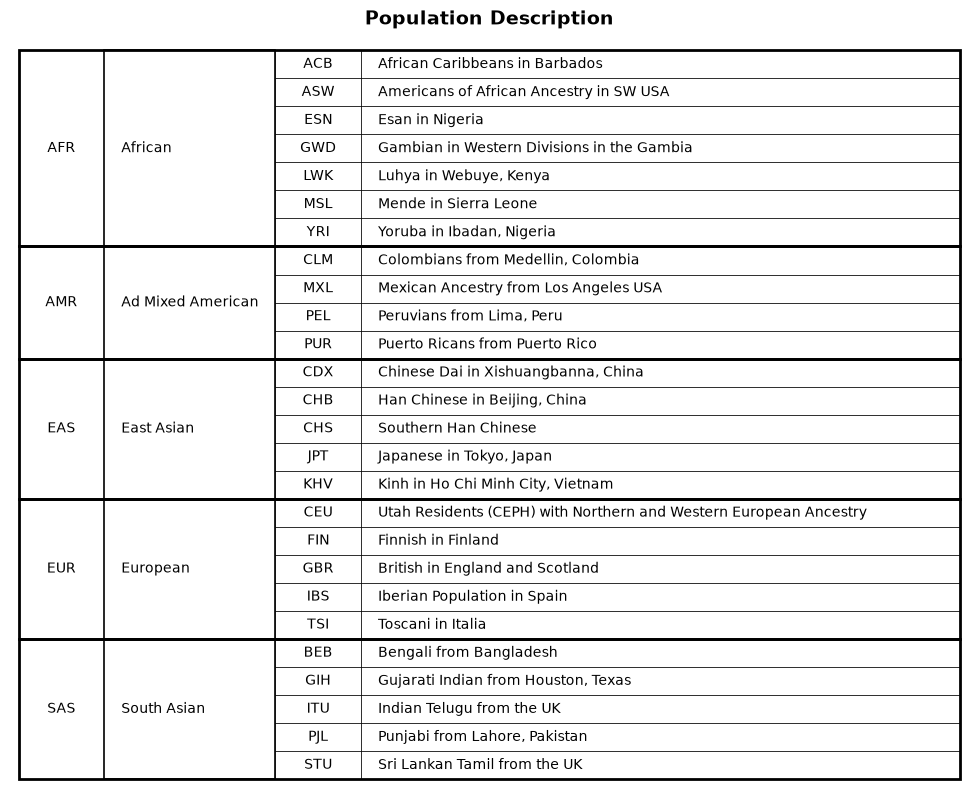

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))
# plt.rcParams["font.family"] = "monospace"
ax.axis("off")

x0_len = 1
x1_len = 2
x2_len = 1
x3_len = 7

ax.set_xlim(
    -0.1,
    x0_len + x1_len + x2_len + x3_len + 0.1,
)
ax.set_ylim(
    len(pop_names) + 0.1,
    -0.1,
)  # reverse y-axis

k = 0
for spop, pops in pop_names_dict.items():
    # super pop
    rect = plt.Rectangle(
        (
            0,
            k,
        ),
        x0_len + x1_len + x2_len + x3_len,
        len(pops),
        fill=False,
        edgecolor="#000000",
        zorder=20,
        lw=2,
    )
    ax.add_patch(rect)
    ax.text(
        0 + 0.5,
        k + (len(pops) / 2),
        spop,
        ha="center",
        va="center",
        fontsize=10,
    )

    # super pop description
    rect = plt.Rectangle(
        (
            x0_len,
            k,
        ),
        x1_len,
        len(pops),
        fill=False,
        edgecolor="#000000",
        zorder=10,
        lw=1.2,
    )
    ax.add_patch(rect)
    ax.text(
        x0_len + 0.2,
        k + (len(pops) / 2),
        spop_desc[spop],
        ha="left",
        va="center",
        fontsize=10,
    )

    for pop in pops:
        # pop
        rect = plt.Rectangle(
            (
                x0_len + x1_len,
                k,
            ),
            1,
            1,
            fill=False,
            edgecolor="#000000",
            zorder=0,
            lw=0.4,
        )
        ax.add_patch(rect)
        ax.text(
            x0_len + x1_len + 0.5,
            0.5 + k,
            pop,
            ha="center",
            va="center",
            fontsize=10,
        )

        # pop description
        rect = plt.Rectangle(
            (++
                x0_len + x1_len + x2_len,
                k,
            ),
            x3_len,
            1,
            fill=False,
            edgecolor="#000000",
            zorder=0,
            lw=0.4,
        )
        ax.add_patch(rect)
        ax.text(
            x0_len + x1_len + x2_len + 0.2,
            0.5 + k,
            pop_desc[pop],
            ha="left",
            va="center",
            fontsize=10,
        )
        k += 1


plt.title(
    "Population Description",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

## pairwise matrix

In [58]:
def fig_pairwise(
    title: str,
    df_s: pd.DataFrame,
    df: pd.DataFrame,
    path_fig: Path,
    get_bar_func: Callable[..., plt.Rectangle | None],
    # cmap: mpl.colors.ListedColormap,
):
    y_len = len(super_pop_names) + len(pop_names)
    x_len = len(pop_names)

    fig, ax = plt.subplots(figsize=(20, 10))
    # plt.rcParams["font.family"] = "monospace"
    ax.axis("off")

    x_off = 2
    y_off = 2

    ax.set_xlim(0, x_off + x_len)
    ax.set_ylim(y_off + y_len, 0)  # reverse y-axis

    rect = plt.Rectangle(
        (0, 0),
        x_off + x_len,
        y_off + y_len,
        fill=False,
        edgecolor="#000000",
        zorder=20,
        lw=2,
    )
    ax.add_patch(rect)

    # top left corner
    rect = plt.Rectangle(
        (0, 0),
        x_off,
        y_off,
        fill=False,
        zorder=-15,
        hatch="/////",
        linewidth=0,
    )
    ax.add_patch(rect)

    min_val, max_val = df.min().min(), df.max().max()
    min_sval, max_sval = df_s.min().min(), df_s.max().max()

    gy = 0
    for y0, (y_spop, y_pops) in enumerate(pop_names_dict.items()):

        # header row level 0
        hdr_y0_len = len(y_pops) + 1  # extra one for super pop's values
        rect = plt.Rectangle(
            (
                0,
                y_off + y0 + gy,
            ),
            x_off + x_len,
            hdr_y0_len,
            fill=False,
            edgecolor="#000000",
            zorder=10,
            lw=1,
        )
        ax.add_patch(rect)
        ax.text(
            0.5,
            y_off + y0 + gy + (hdr_y0_len / 2),
            y_spop,
            ha="center",
            va="center",
            fontsize=11,
        )

        # header col level 0
        hdr_x0_len = len(
            y_pops
        )  # x_pops hasn't defined in this block, thus use y_pops instead
        rect = plt.Rectangle(
            (
                x_off + gy,
                0,
            ),
            hdr_x0_len,
            y_off + y_len,
            fill=False,
            edgecolor="#000000",
            zorder=10,
            lw=1,
        )
        ax.add_patch(rect)
        ax.text(
            x_off + gy + (hdr_x0_len / 2),
            0.5,
            y_spop,
            ha="center",
            va="center",
            fontsize=11,
        )

        for y1, y_pop in enumerate(y_pops):
            # header row level 1
            rect = plt.Rectangle(
                (
                    1,
                    y_off + y0 + gy,
                ),
                1,
                1,
                fill=False,
                edgecolor="#000000",
                zorder=10,
                lw=1,
            )
            ax.add_patch(rect)
            ax.text(
                0.5 + 1,
                0.5 + y_off + y0 + gy,
                y_pop,
                ha="center",
                va="center",
                fontsize=11,
            )

            # header col level 1
            rect = plt.Rectangle(
                (x_off + gy, 1),
                1,
                1,
                fill=False,
                edgecolor="#000000",
                zorder=10,
                lw=1,
            )
            ax.add_patch(rect)
            ax.text(
                0.5 + x_off + gy,
                0.5 + 1,
                y_pop,
                ha="center",
                va="center",
                fontsize=11,
            )

            gx = 0
            for x0, (x_spop, x_pops) in enumerate(pop_names_dict.items()):

                for x1, x_pop in enumerate(x_pops):
                    _gx = x_off + gx
                    _gy = y_off + gy + y0

                    # super pop value
                    if y1 == 0 and x1 == 0:
                        if y_spop != x_spop:
                            sval = df_s.loc[y_spop, x_spop]
                            ax.text(
                                _gx + (len(x_pops) / 2),
                                _gy + 0.5 + len(y_pops),
                                f"{sval:.4f}",
                                ha="center",
                                va="center",
                                fontsize=10,
                            )
                            # bar
                            bar = get_bar_func(
                                gx1=gx + x_off,
                                gy1=gy + y_off + y0 + len(y_pops),
                                gx2=gx + x_off + len(x_pops),
                                gy2=gy + y_off + y0 + len(y_pops),
                                min_val=min_sval,
                                max_val=max_sval,
                                val=sval,
                            )
                            if bar is not None:
                                ax.add_patch(bar)
                        else:
                            bar = plt.Rectangle(
                                (_gx, _gy + len(y_pops)),
                                len(x_pops),
                                1,
                                fill=False,
                                zorder=-10,
                                hatch="/////",
                                linewidth=0,
                            )
                            ax.add_patch(bar)

                    # pop value
                    if y_pop != x_pop:
                        val = df.loc[(y_spop, y_pop), (x_spop, x_pop)]
                        ax.text(
                            0.5 + _gx,
                            0.5 + _gy,
                            f"{val:.4f}",
                            ha="center",
                            va="center",
                            fontsize=10,
                        )
                        # bar
                        bar = get_bar_func(
                            gx1=gx + x_off,
                            gy1=gy + y_off + y0,
                            gx2=gx + x_off + 1,
                            gy2=gy + y_off + y0 + 1,
                            min_val=min_val,
                            max_val=max_val,
                            val=val,
                        )
                        if bar is not None:
                            ax.add_patch(bar)

                    else:
                        bar = plt.Rectangle(
                            (_gx, _gy),
                            1,
                            1,
                            fill=False,
                            zorder=-10,
                            hatch="/////",
                            linewidth=0,
                        )
                        ax.add_patch(bar)

                    # grid
                    rect = plt.Rectangle(
                        (
                            x_off + gx,
                            y_off + gy + y0,
                        ),
                        1,
                        1,
                        fill=False,
                        edgecolor="#000000",
                        zorder=-5,
                        lw=1,
                    )
                    ax.add_patch(rect)
                    gx += 1

            gy += 1

    plt.title(
        title,
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(path_fig, dpi=300, bbox_inches="tight")
    plt.show()

## fst distance

In [59]:
def mute_cmap(
    cmap: mpl.colors.ListedColormap,
    desaturate: float,
    brighten: float,
):
    assert desaturate >= 0 and desaturate <= 1
    assert brighten >= 0 and brighten <= 1
    rgb = cmap(np.linspace(0, 1, 256))
    hsv = mpl.colors.rgb_to_hsv(rgb[:, :3])
    hsv[:, 1] *= desaturate
    hsv[:, 2] = np.clip(hsv[:, 2] * (1 + brighten), 0, 1)
    return mpl.colors.ListedColormap(
        np.column_stack((mpl.colors.hsv_to_rgb(hsv), rgb[:, 3])),name=f"{cmap.name}_muted"
    )

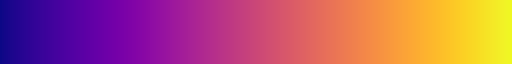

In [60]:
_cmap_fst_dist = plt.colormaps.get("plasma")
_cmap_fst_dist

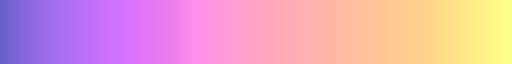

In [61]:
cmap_fst_dist = mute_cmap(_cmap_fst_dist, 0.55, 0.5)
cmap_fst_dist

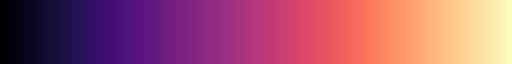

In [62]:
ori_cmap_2 = plt.colormaps.get("magma")
ori_cmap_2

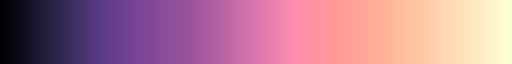

In [63]:
cmap_2 = mute_cmap(ori_cmap_2, 0.65, 0.2)
cmap_2

In [64]:
def get_bar_fst_distance(
    gx1: float,
    gy1: float,
    gx2: float,
    gy2: float,
    min_val,
    max_val,
    val,
) -> plt.Rectangle | None:
    if val == 0:
        return None
    bar_len = (val - min_val) / (max_val - min_val) * (gx2 - gx1)
    bar = plt.Rectangle(
        (gx1, gy1),
        bar_len,
        1,
        # color="#FFFF80",
        color=cmap_fst_dist((0.25 - min(0.25, val)) / 0.25),
        alpha=1,
        zorder=-10,
    )
    return bar

### all

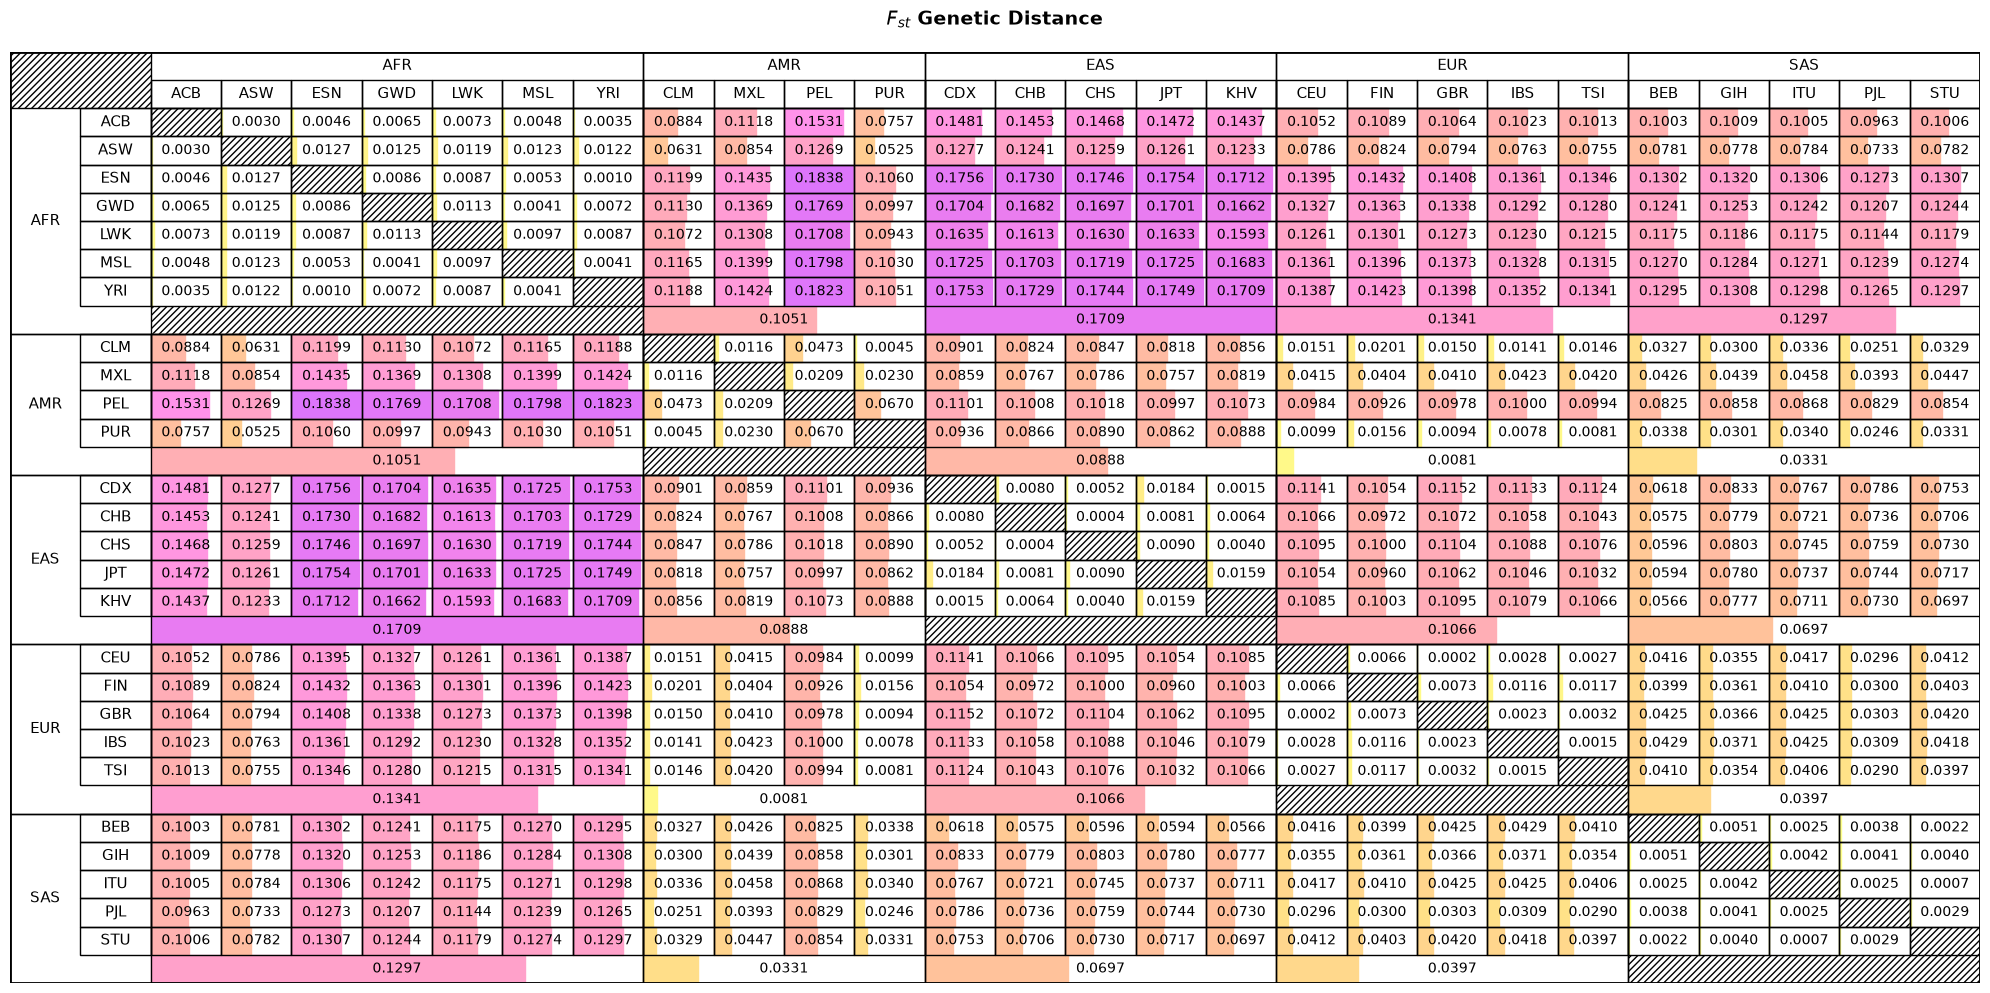

In [65]:
fig_pairwise(
    r"$F_{st}$ Genetic Distance",
    df_fst_sa,
    df_fst_a,
    PATH_OUT_FIG_FST_A,
    get_bar_fst_distance,
)

### females

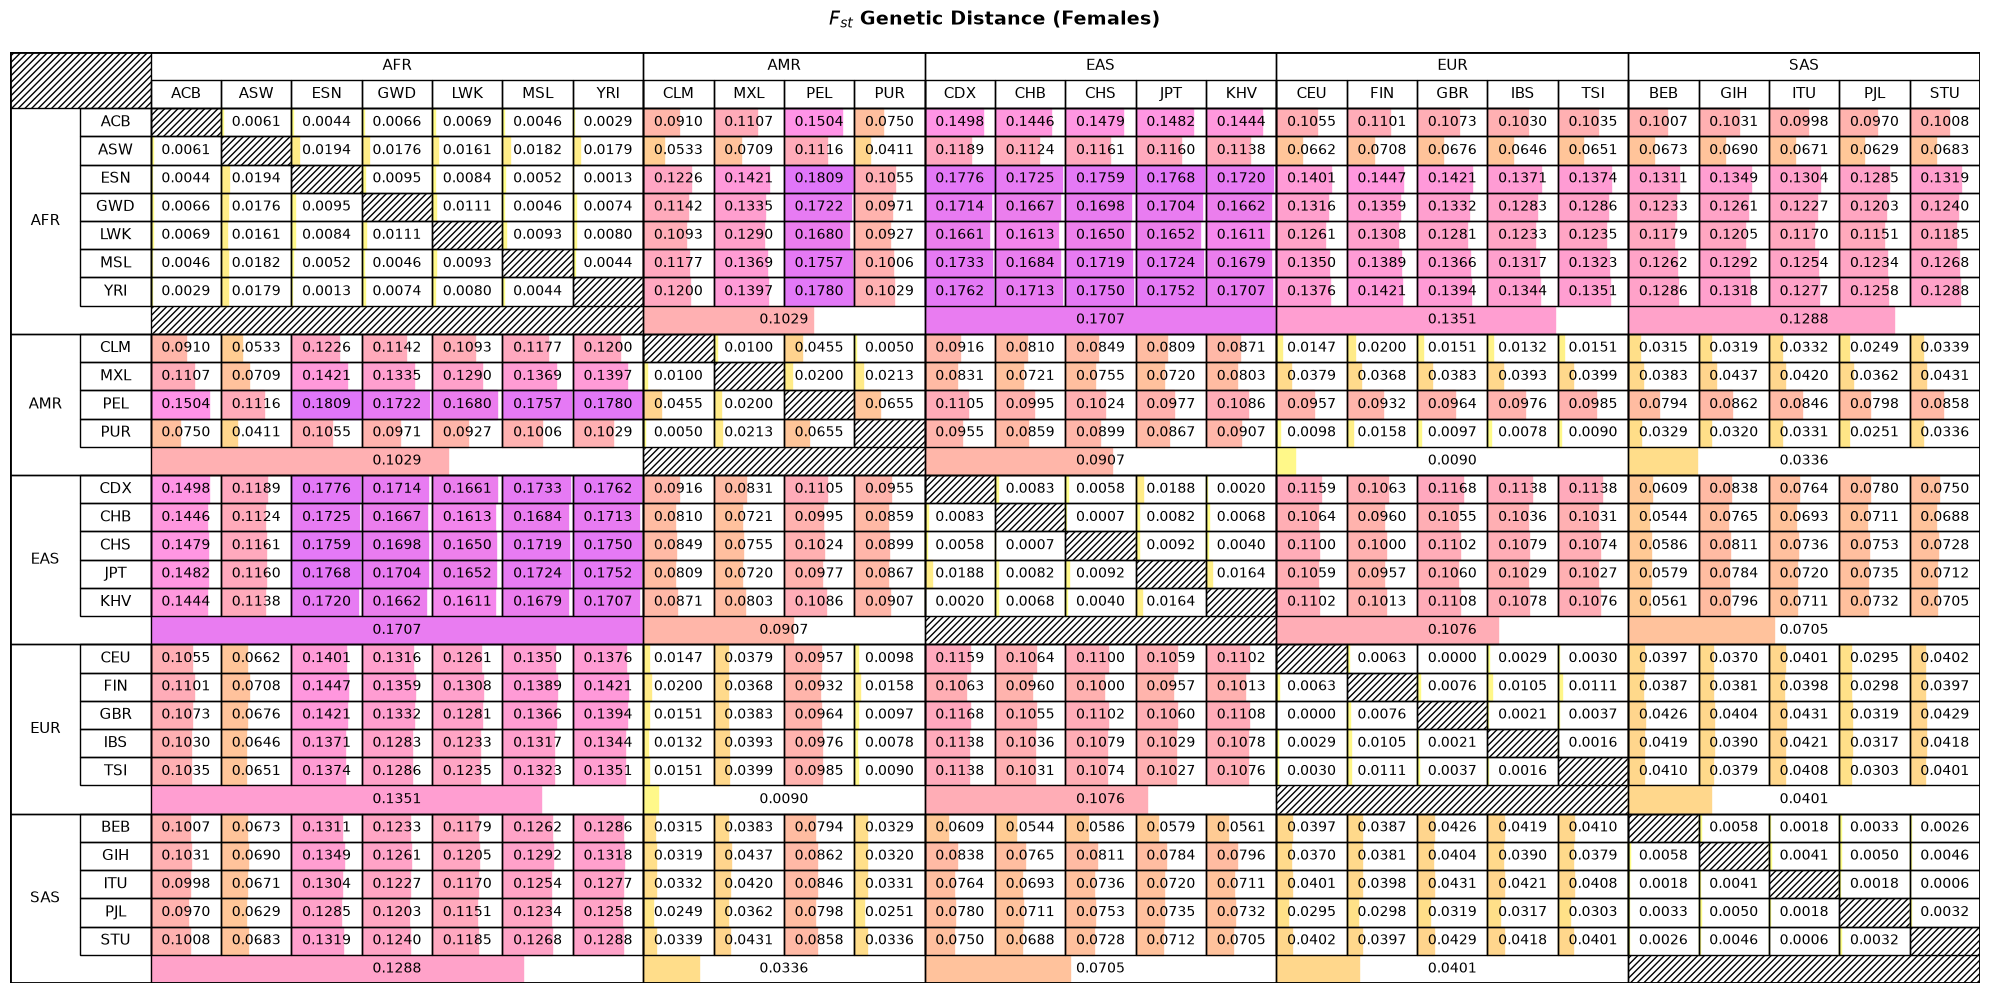

In [66]:
fig_pairwise(
    r"$F_{st}$ Genetic Distance (Females)",
    df_fst_sf,
    df_fst_f,
    PATH_OUT_FIG_FST_F,
    get_bar_fst_distance,
)

### males

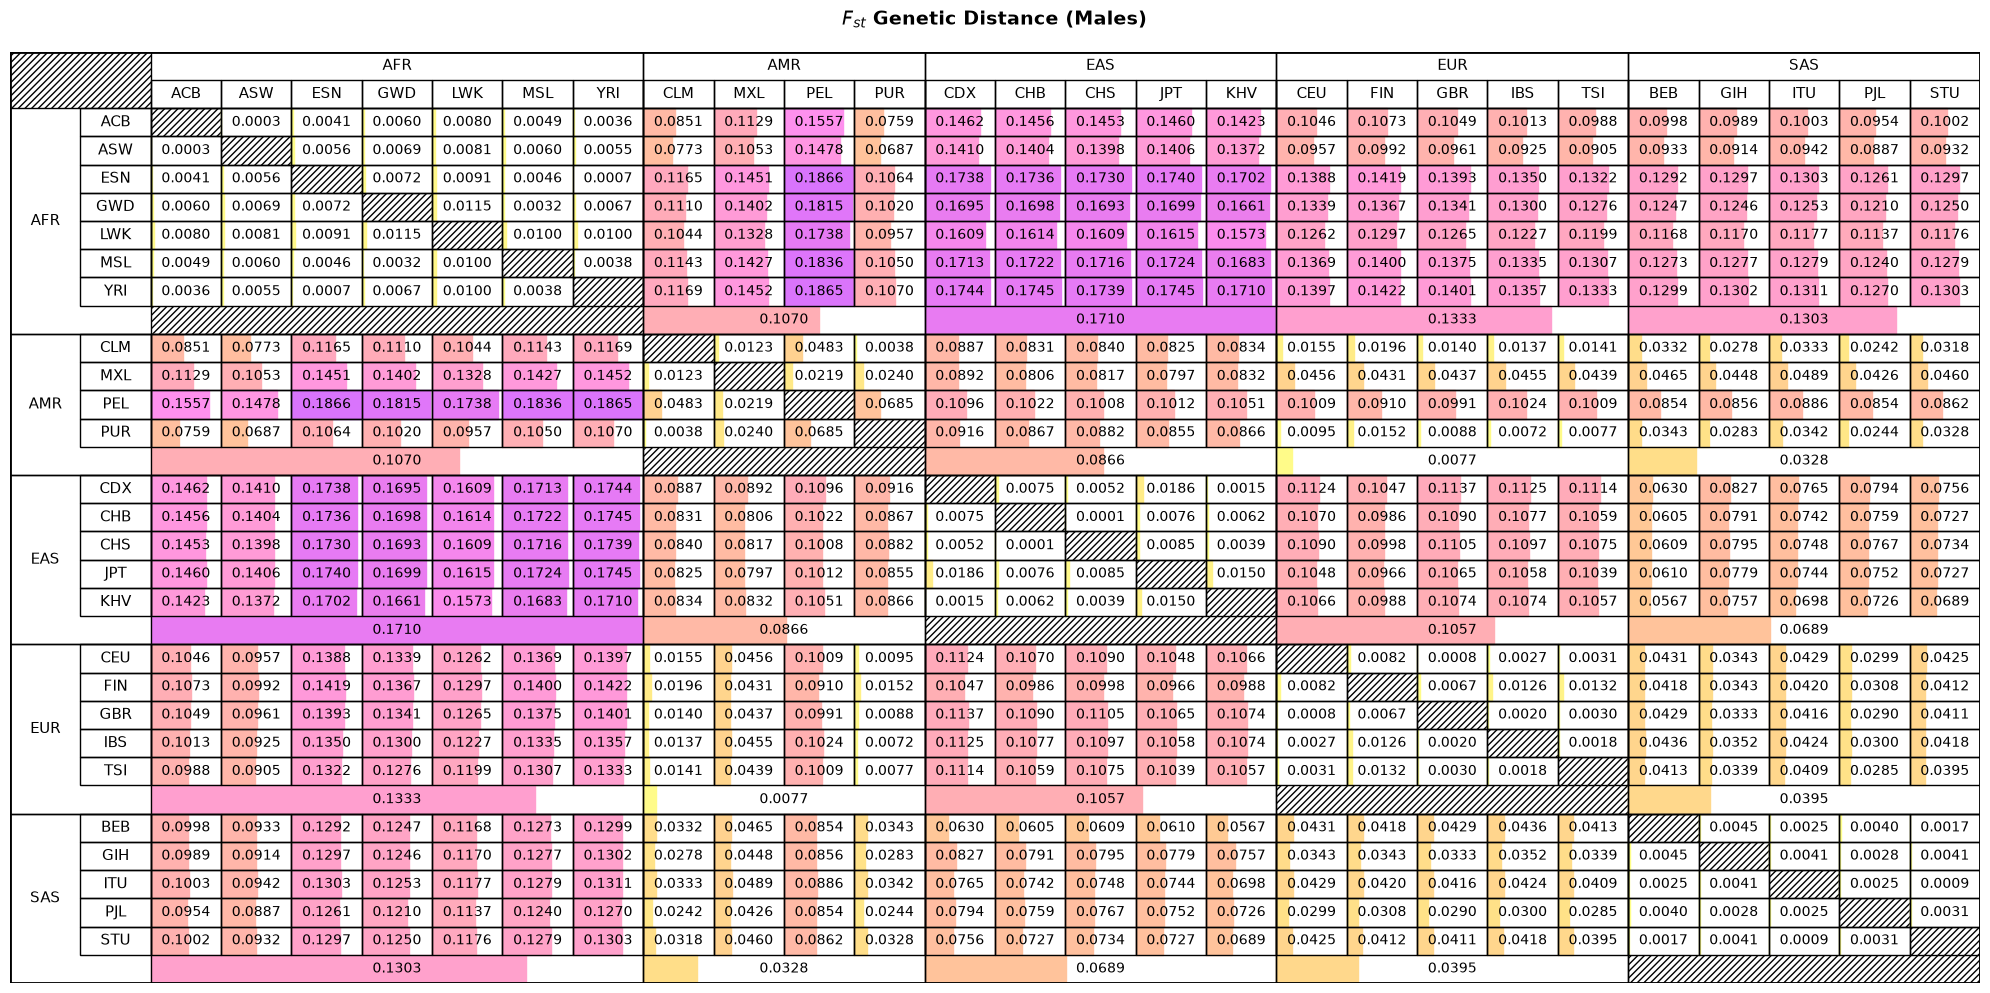

In [67]:
fig_pairwise(
    r"$F_{st}$ Genetic Distance (Males)",
    df_fst_sm,
    df_fst_m,
    PATH_OUT_FIG_FST_M,
    get_bar_fst_distance,
)

## sex-biased dispersion

In [68]:
def get_bar_abs_diff(
    gx1: float,
    gy1: float,
    gx2: float,
    gy2: float,
    min_val,
    max_val,
    val,
) -> plt.Rectangle | None:
    if val == 0:
        return None

    abs_max_val = max(max_val, abs(min_val))
    bar_len = val / abs_max_val * (gx2 - gx1)
    gx = gx1 if bar_len > 0 else gx1 + (gx2 - gx1)
    color = "#aaaaff" if bar_len > 0 else "#ffaaaa"

    bar = plt.Rectangle(
        (gx, gy1),
        bar_len,
        1,
        color=color,
        # color=cmap_1((0.25 - min(0.25, val)) / 0.25),
        alpha=1,
        zorder=-10,
    )

    return bar


### absolute difference

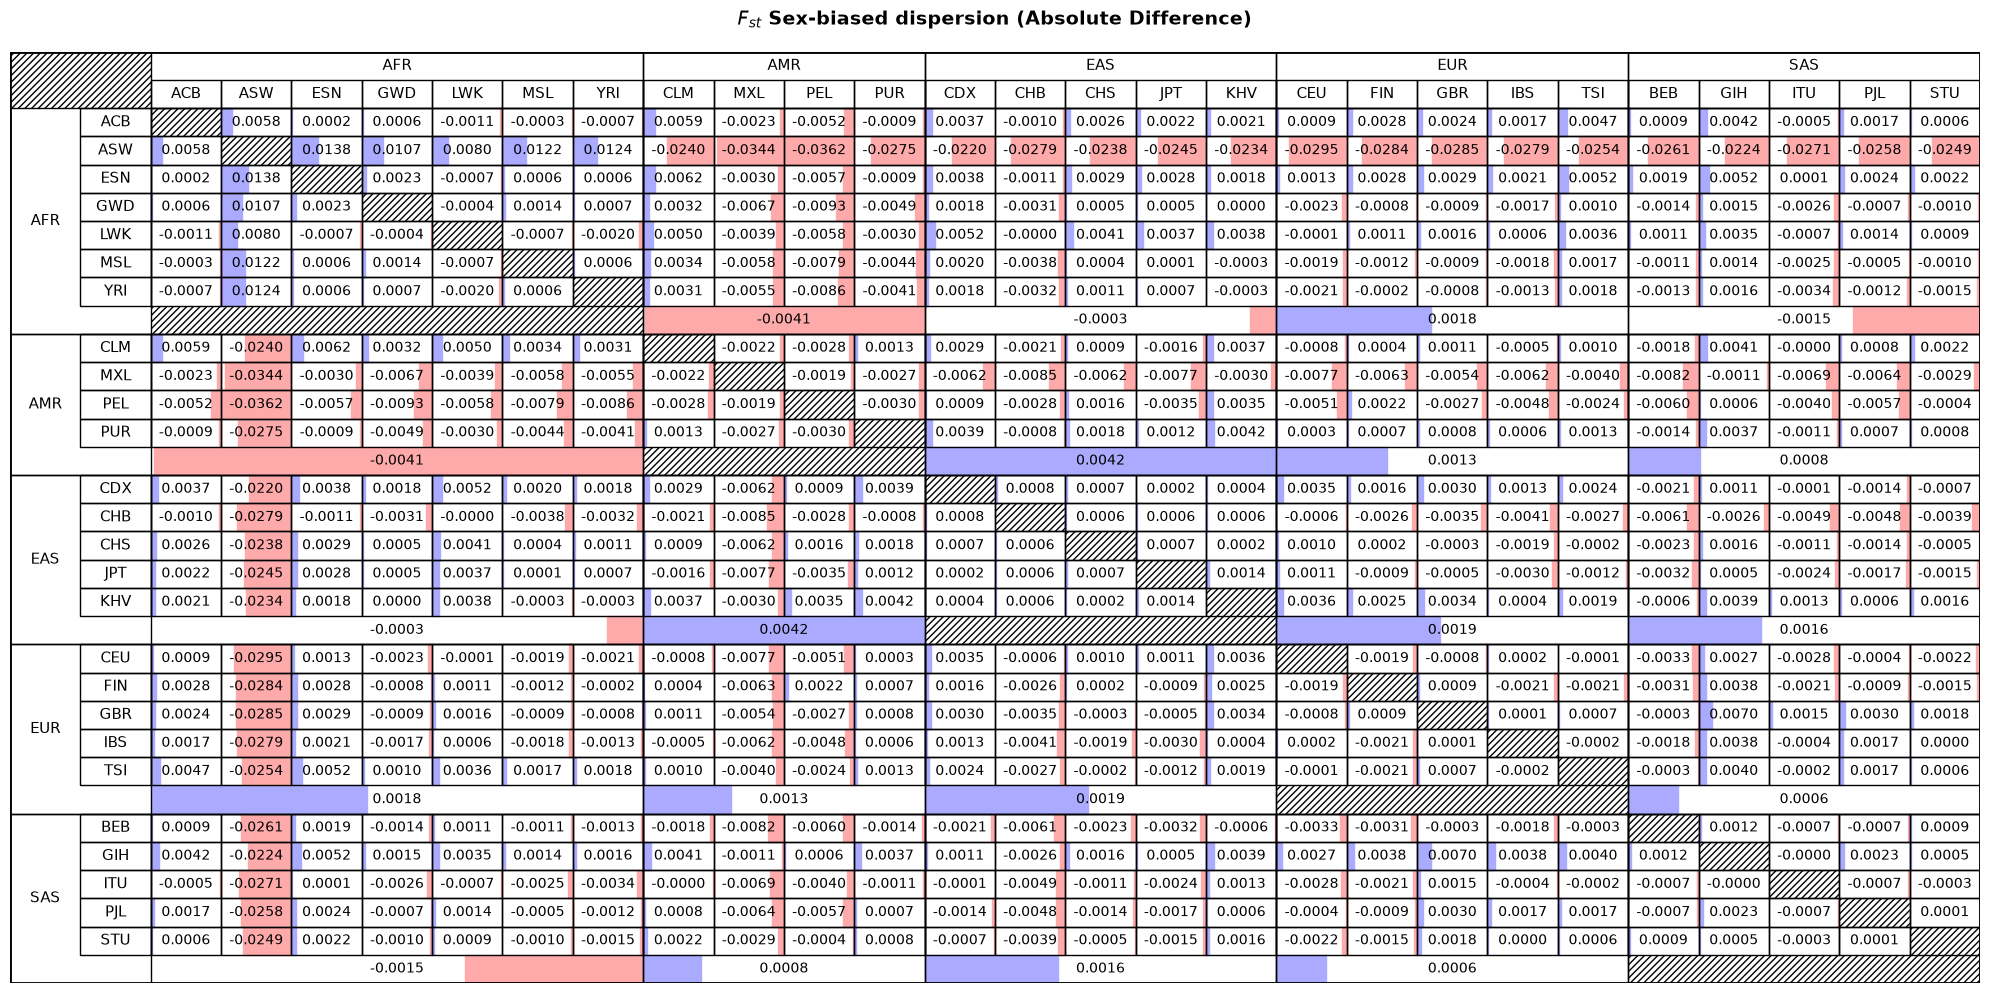

In [69]:
fig_pairwise(
    r"$F_{st}$ Sex-biased dispersion (Absolute Difference)",
    df_abs_diff_s,
    df_abs_diff,
    PATH_OUT_FIG_ABS_DIFF,
    get_bar_abs_diff,
)

### relative difference

In [70]:
def get_bar_rel_diff(
    gx1: float,
    gy1: float,
    gx2: float,
    gy2: float,
    min_val,
    max_val,
    val,
) -> plt.Rectangle | None:
    # assert -1 <= val <= 1
    if val == 0:
        return None

    if val > 0:
        bar_len = val / (val + 0.1) * (gx2 - gx1)
        gx = gx1
        color = "#aaaaff"
    elif val < 0:
        # bar_len = -(max(-2, val) + 1) / (max(-2, min_val) + 1) * (gx2 - gx1)
        bar_len = val / (-val + 0.1) * (gx2 - gx1)
        gx = gx1 + (gx2 - gx1)
        color = "#ffaaaa"
    else:
        assert False

    
    # # abs_max_val = max(max_val, abs(min_val))
    # bar_len = val * (gx2 - gx1)
    # gx = gx1 if bar_len > 0 else gx1 + (gx2 - gx1)
    # color = "#aaaaff" if bar_len > 0 else "#ffaaaa"

    bar = plt.Rectangle(
        (gx, gy1),
        bar_len,
        1,
        color=color,
        alpha=1,
        zorder=-10,
    )

    return bar


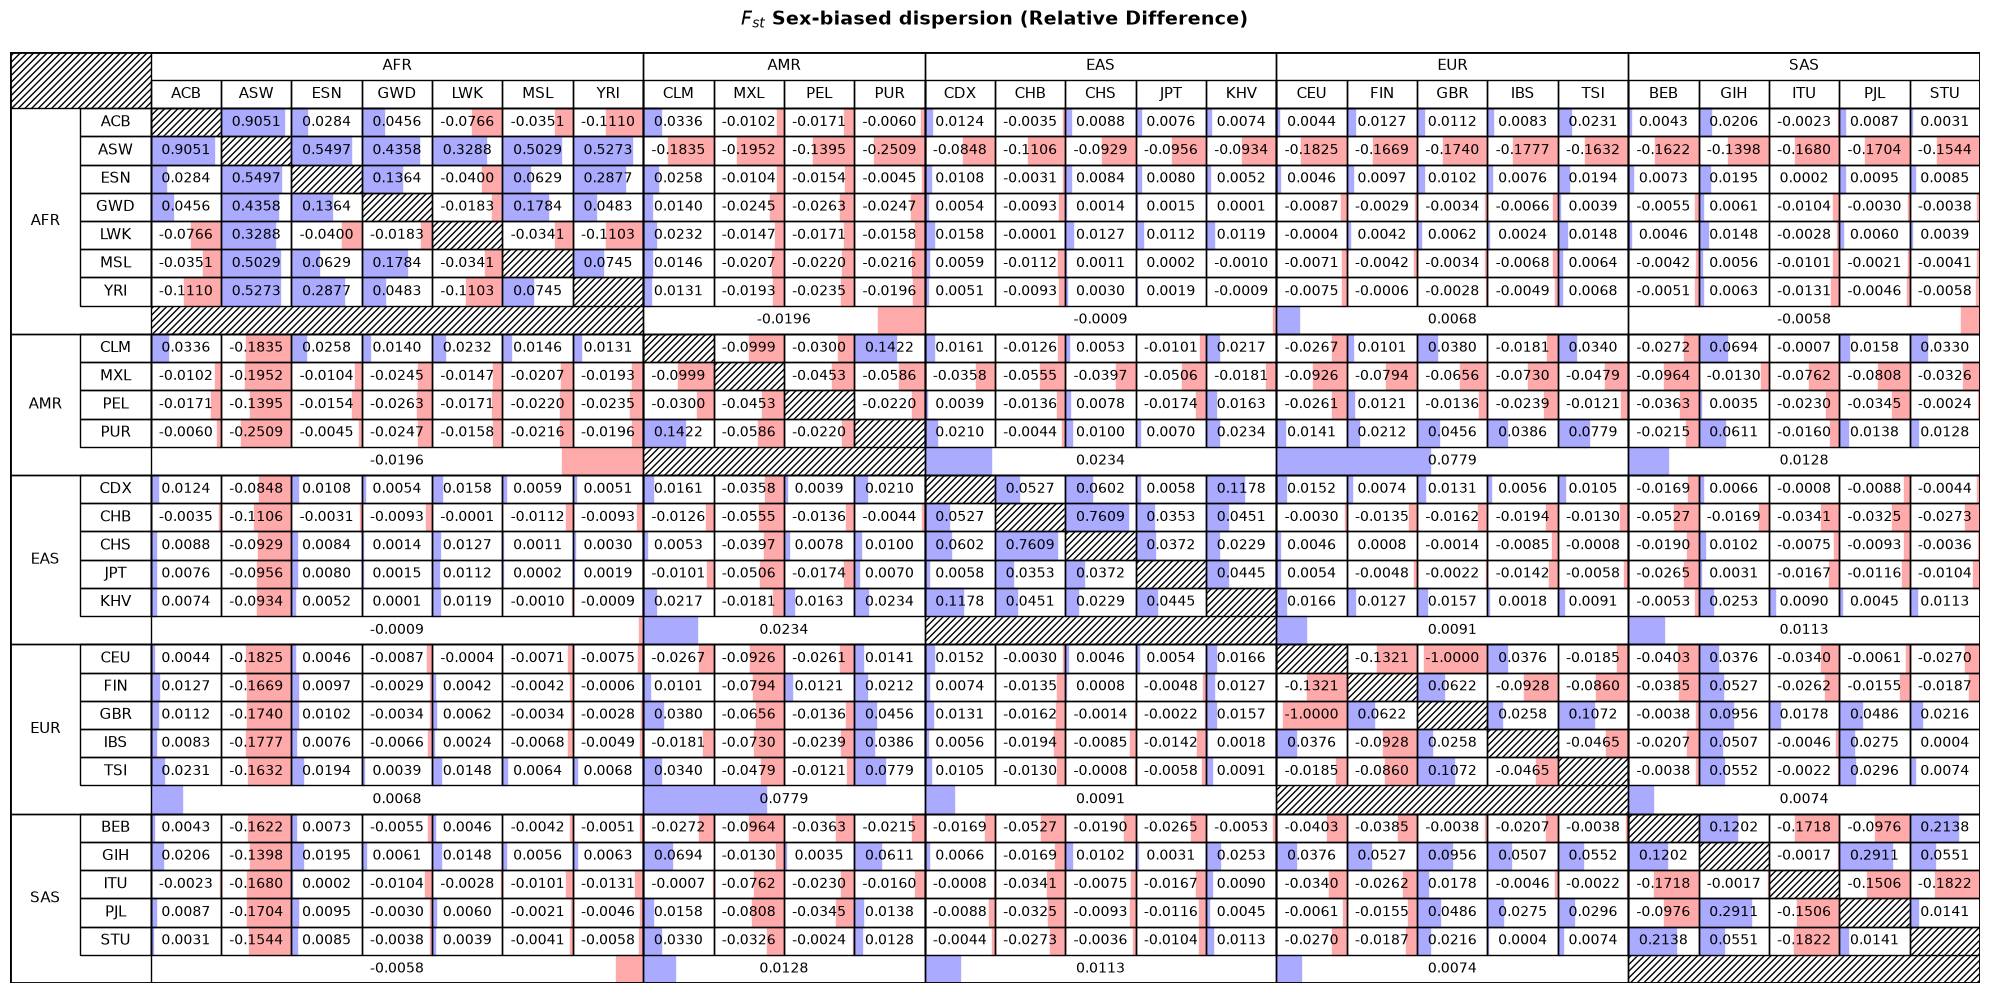

In [71]:
fig_pairwise(
    r"$F_{st}$ Sex-biased dispersion (Relative Difference)",
    df_rel_diff_s,
    df_rel_diff,
    PATH_OUT_FIG_REL_DIFF,
    get_bar_rel_diff,
)

### migration ratio

In [72]:
def get_bar_migr_ratio(
    gx1: float,
    gy1: float,
    gx2: float,
    gy2: float,
    min_val,
    max_val,
    val,
) -> plt.Rectangle | None:

    assert val >= 1 or val <= -1
    
    if val == 1:
        return None

    if val > 1:
        bar_len = (min(2, val) - 1) / (min(2, max_val) - 1) * (gx2 - gx1)
        gx = gx1
        color = "#aaaaff"
    elif val < -1:
        bar_len = -(max(-2, val) + 1) / (max(-2, min_val) + 1) * (gx2 - gx1)
        gx = gx1 + (gx2 - gx1)
        color = "#ffaaaa"
    else:
        assert False

    bar = plt.Rectangle(
        (gx, gy1),
        bar_len,
        1,
        color=color,
        alpha=1,
        zorder=-10,
    )

    return bar

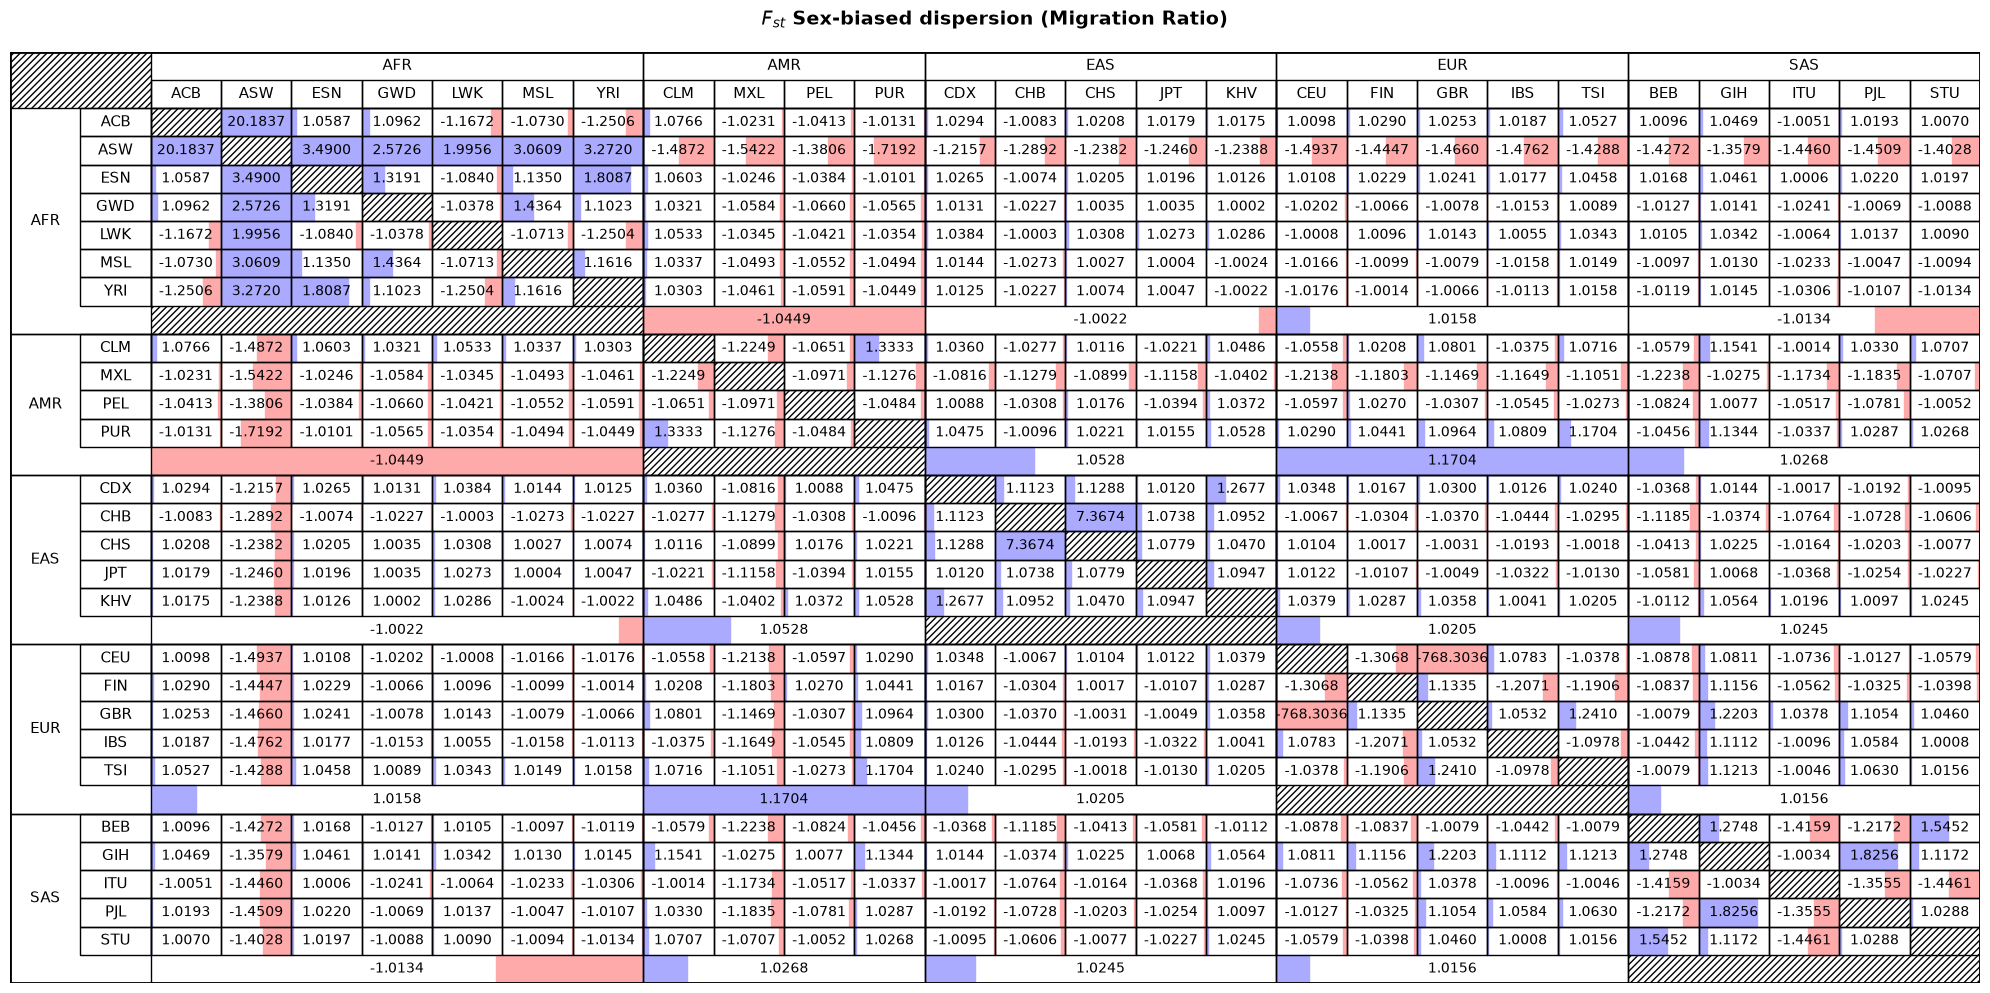

In [73]:
fig_pairwise(
    r"$F_{st}$ Sex-biased dispersion (Migration Ratio)",
    df_migr_ratio_s,
    df_migr_ratio,
    PATH_OUT_FIG_MIGR_RATIO,
    get_bar_migr_ratio,
)